# A2 — Reconhecimento semântico em publicidade visual com CLIP (ADS-16)

**Como executar:** Google Colab com GPU T4 (*Ambiente de execução > Alterar o tipo de ambiente de
execução > T4 GPU*) e *Executar tudo*. Nenhum modelo é treinado: o notebook usa só os embeddings de
um CLIP pré-treinado.

| | Execução completa |
|---|---|
| Tempo estimado de execução | ~2,5 min (134 s medidos, incluindo o download de 1,47 GB do dataset, que levou de 26 a 54 s nas execuções de 04/10) |
| Pico de VRAM alocada (reservada) | 2,98 GB (3,38 GB), na extração dos embeddings das imagens |
| Pico de RAM do processo | 3,2 GB |

> Medido no Colab T4 em 04/10/2026: tabela de tempo e memória no apêndice (detalhe por etapa em
> `report_assets/tempos_execucao.csv`). **VRAM alocada** = memória dos tensores do PyTorch; a
> **reservada** inclui o cache do alocador e fica mais perto do `nvidia-smi`; nenhuma inclui o contexto
> CUDA. A RAM é o pico do processo (`ru_maxrss`).

## Setup

Clone do código (`src/`), pasta de saída, imports e configuração. O código dos módulos está no
repositório; o notebook só orquestra.

In [1]:
import os
import subprocess
import time

_T_INICIO_NOTEBOOK = time.perf_counter()  # tempo total do notebook (R15)
TEMPOS = []  # registro das etapas cronometradas

REPO_URL = "https://github.com/anacaetano02/Deep-Learning-Visao-Computacional.git"
SUBPASTA = "A2_clip_ads16"
REPO_DIR = "/content/repo"
# Versão do código: a tag da versão entregue fixa o src/ que gerou os resultados (os commits
# seguintes do repositório, das outras atividades, não mudam esta execução). None = branch principal.
GIT_REF = "a2-entrega"

PROJECT_DIR = os.path.join(REPO_DIR, SUBPASTA)

if not os.path.isdir(os.path.join(REPO_DIR, ".git")):
    # --filter=blob:none + --sparse: baixa só os arquivos da pasta da A2, não o repositório inteiro
    ref = ["--branch", GIT_REF] if GIT_REF else []
    subprocess.run(["git", "clone", "--filter=blob:none", "--sparse", "--depth", "1", *ref, REPO_URL, REPO_DIR],
                   check=True)
    subprocess.run(["git", "sparse-checkout", "set", SUBPASTA], cwd=REPO_DIR, check=True)
elif GIT_REF:
    # Já clonado nesta sessão: garante a versão fixada (não puxa commits novos)
    subprocess.run(["git", "fetch", "--depth", "1", "origin", "tag", GIT_REF], cwd=REPO_DIR, check=True)
    subprocess.run(["git", "checkout", GIT_REF], cwd=REPO_DIR, check=True)
else:
    print(f"Repositório já clonado em '{REPO_DIR}': buscando mudanças mais recentes...")
    subprocess.run(["git", "pull"], cwd=REPO_DIR, check=True)

TEMPOS.append({"etapa": "clone/pull do repositório", "segundos": round(time.perf_counter() - _T_INICIO_NOTEBOOK, 1)})

In [2]:
import importlib, sys

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

# Ao reexecutar o notebook na mesma sessão depois de atualizar o código, recarrega os módulos src.*
# já importados. Num runtime novo não há nada para recarregar e a célula não faz nada.
for nome in sorted(m for m in sys.modules if m == "src" or m.startswith("src.")):
    importlib.reload(sys.modules[nome])

In [3]:
# Onde salvar os artefatos desta execução (embeddings, tabelas, figuras).
# * False (padrão): disco local do Colab, em /content (apagado quando o runtime é desconectado).
# * True: Google Drive (pede autorização no início).
from pathlib import Path

SALVAR_NO_DRIVE = False

if SALVAR_NO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/deep_learning_visao_computacional/A2_clip_ads16")
else:
    BASE_DIR = Path("/content/A2_clip_ads16_saida")

DIR_DADOS = BASE_DIR / "data"
DIR_OUTPUTS = BASE_DIR / "outputs"
DIR_REPORT_ASSETS = DIR_OUTPUTS / "report_assets"   # tabelas e figuras que vão para o relatório

for d in (DIR_DADOS, DIR_REPORT_ASSETS):
    d.mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR = {BASE_DIR} (Drive: {SALVAR_NO_DRIVE})")

BASE_DIR = /content/A2_clip_ads16_saida (Drive: False)


In [4]:
# Configuração do experimento (decisões do aluno; justificar em markdown)
SEED = 42
CHECKPOINT_CLIP = "openai/clip-vit-large-patch14-336"
REVISAO_CLIP = "ce19dc912ca5cd21c8a653c79e251e808ccabcd1"  # SHA do commit no Hub: fixa pesos e processor
DIM_EMBEDDING = 768    # projection_dim do checkpoint (espaço compartilhado imagem-texto)
RESOLUCAO_CLIP = 336   # lado da imagem de entrada do checkpoint
TAMANHO_LOTE = 32      # imagens por lote na extração dos embeddings

## Dados: ADS-16 (R1, R2)

**Origem.** ADS-16 (Computational Advertising Dataset), Kaggle `groffo/ads16-dataset`, **versão 1**,
baixado com o `kagglehub` (dataset público, sem credenciais). Citação pedida pelos autores: Roffo, G.,
& Vinciarelli, A. (2016). *Personality in computational advertising: A benchmark.* 4th Workshop on
Emotions and Personality in Personalized Systems (EMPIRE), p. 18.

**Versão garantida pela impressão digital.** Em algumas execuções, o `kagglehub` usou o cache do
próprio Colab (`/kaggle/input/...`), cujo caminho não mostra a versão; em outras, baixou o arquivo de
fato (1,47 GB em `.../ads16-dataset/versions/1`). Nos dois casos, a impressão digital conferida por
`assert` é a mesma: **3.429 arquivos, 1.582,9 MB, assinatura `e9071258c790f1e9`** (hash da lista
caminho|tamanho). É ela, e não o caminho, que garante que os dados são os mesmos.

**Estrutura.** Duas partes (`part1`, `part2`), cada uma com:
- `Ads/`: os anúncios, em `Ads/Ads/<categoria 1..20>/<n>.png` (151 + 150 arquivos);
- `Corpus/`: dados dos 120 participantes do estudo original (fotos pessoais, ratings, Big Five);
- `Documents/`: o artigo em PDF.

Os 6 `.zip` são os arquivos originais, já extraídos nas pastas ao lado (não escondem anúncios), e o
único `.jpg` é uma foto pessoal em `Corpus/`. O dataset tem **20 categorias**: o "16" do nome é o ano.

In [5]:
import kagglehub

from src.dados import ASSINATURA_DATASET, N_ARQUIVOS_DATASET, impressao_digital

# Versão do dataset no Kaggle. No Colab, o kagglehub pode servir o cache do próprio Colab
# (/kaggle/input/...), cujo caminho não mostra a versão: quem garante que os dados são os mesmos
# é a impressão digital (nº de arquivos + hash da lista caminho|tamanho).
VERSAO_ADS16 = 1

_t0 = time.perf_counter()
DIR_ADS16 = Path(kagglehub.dataset_download(f"groffo/ads16-dataset/versions/{VERSAO_ADS16}"))
TEMPOS.append({"etapa": "download do ADS-16", "segundos": round(time.perf_counter() - _t0, 1)})
print(DIR_ADS16)

n_arquivos, mb, assinatura = impressao_digital(DIR_ADS16)
assert (n_arquivos, assinatura) == (N_ARQUIVOS_DATASET, ASSINATURA_DATASET), "O conteúdo do ADS-16 mudou"
print(f"{n_arquivos} arquivos, {mb} MB, assinatura {assinatura}")

100%|██████████| 1.47G/1.47G [00:11<00:00, 143MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/groffo/ads16-dataset/versions/1
3429 arquivos, 1582.9 MB, assinatura e9071258c790f1e9


In [6]:
from collections import Counter

from src.dados import arvore

arvore(DIR_ADS16)

ADS16_Benchmark_part1/  (1675 arquivos)
    ADS16_Benchmark_part1/  (1671 arquivos)
        Ads/  (151 arquivos)
        Corpus/  (1518 arquivos)
        Documents/  (1 arquivos)
ADS16_Benchmark_part2/  (1754 arquivos)
    ADS16_Benchmark_part2/  (1750 arquivos)
        Ads/  (150 arquivos)
        Corpus/  (1598 arquivos)
        Documents/  (1 arquivos)


In [7]:
# Extensões no dataset inteiro. Os 6 .zip são os originais (Ads/Corpus/Documents de cada parte),
# já extraídos nas pastas ao lado: não escondem anúncios. O único .jpg está em Corpus/ (foto pessoal).
extensoes = Counter(p.suffix.lower() for p in DIR_ADS16.rglob("*") if p.is_file())
print(extensoes.most_common())
print(sorted(str(p.relative_to(DIR_ADS16)) for p in DIR_ADS16.rglob("*.zip")))

[('.png', 2696), ('.csv', 720), ('.zip', 6), ('.txt', 4), ('.pdf', 2), ('.jpg', 1)]
['ADS16_Benchmark_part1/Ads.zip', 'ADS16_Benchmark_part1/Corpus.zip', 'ADS16_Benchmark_part1/Documents.zip', 'ADS16_Benchmark_part2/Ads.zip', 'ADS16_Benchmark_part2/Corpus.zip', 'ADS16_Benchmark_part2/Documents.zip']


In [8]:
from PIL import Image

from src.dados import N_ARQUIVOS_ADS, N_CATEGORIAS, carregar_imagem, listar_anuncios

# Corpus = só os anúncios (Ads/); Corpus/ (fotos pessoais) e Documents/ ficam de fora.
anuncios = listar_anuncios(DIR_ADS16)
por_categoria = anuncios.groupby("categoria").size()
assert len(anuncios) == N_ARQUIVOS_ADS, len(anuncios)
assert sorted(por_categoria.index) == list(range(1, N_CATEGORIAS + 1)), por_categoria
print(f"{len(anuncios)} arquivos de anúncio em {por_categoria.size} categorias")
print("Categorias fora do padrão de 15:", por_categoria[por_categoria != 15].to_dict())

# Duplicatas exatas (mesmo conteúdo em bytes): mantém a primeira ocorrência
duplicatas = anuncios[anuncios.duplicated("md5", keep=False)]
print(f"Duplicatas exatas: {len(duplicatas)} arquivos")
if len(duplicatas):
    display(duplicatas[["caminho_rel", "categoria", "n", "largura", "altura"]])

corpus = anuncios.drop_duplicates("md5", keep="first").reset_index(drop=True)
corpus["caminho"] = [str(DIR_ADS16 / c) for c in corpus["caminho_rel"]]
corpus.drop(columns="caminho").to_csv(DIR_REPORT_ASSETS / "corpus_ads16.csv", index=False)
print(f"Corpus final: {len(corpus)} anúncios")

301 arquivos de anúncio em 20 categorias
Categorias fora do padrão de 15: {1: 16}
Duplicatas exatas: 0 arquivos
Corpus final: 301 anúncios


Modos de cor: [('RGB', 292), ('RGBA', 5), ('P', 4)]
Com transparência (compostos sobre fundo branco): 0 anúncios


,largura,altura,proporcao
count,301.00,301.00,301.00
mean,499.82,499.36,1.00
std,8.76,6.93,0.02
min,400.00,400.00,1.00
25%,500.00,500.00,1.00
50%,500.00,500.00,1.00
75%,500.00,500.00,1.00
max,600.00,500.00,1.30


Tamanhos distintos (largura×altura):


,anúncios
500×500,298
400×400,1
600×461,1
445×445,1


Não quadrados: 1 de 301; perda máxima no center crop: 11.6% de cada lado do lado maior
Redução de escala no CLIP: ~500 px -> 336 px (fator 0.67)


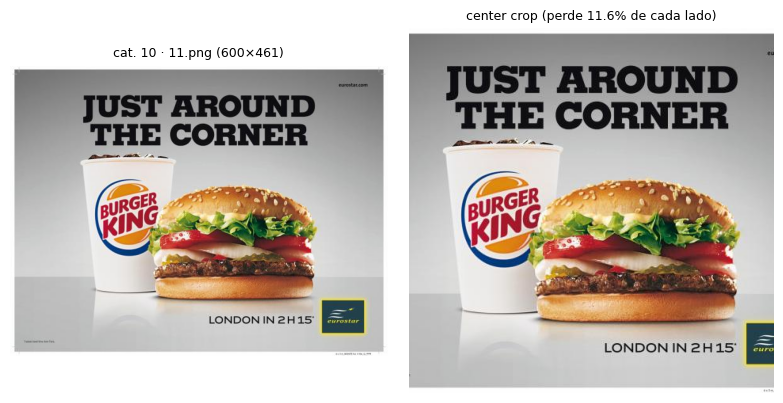

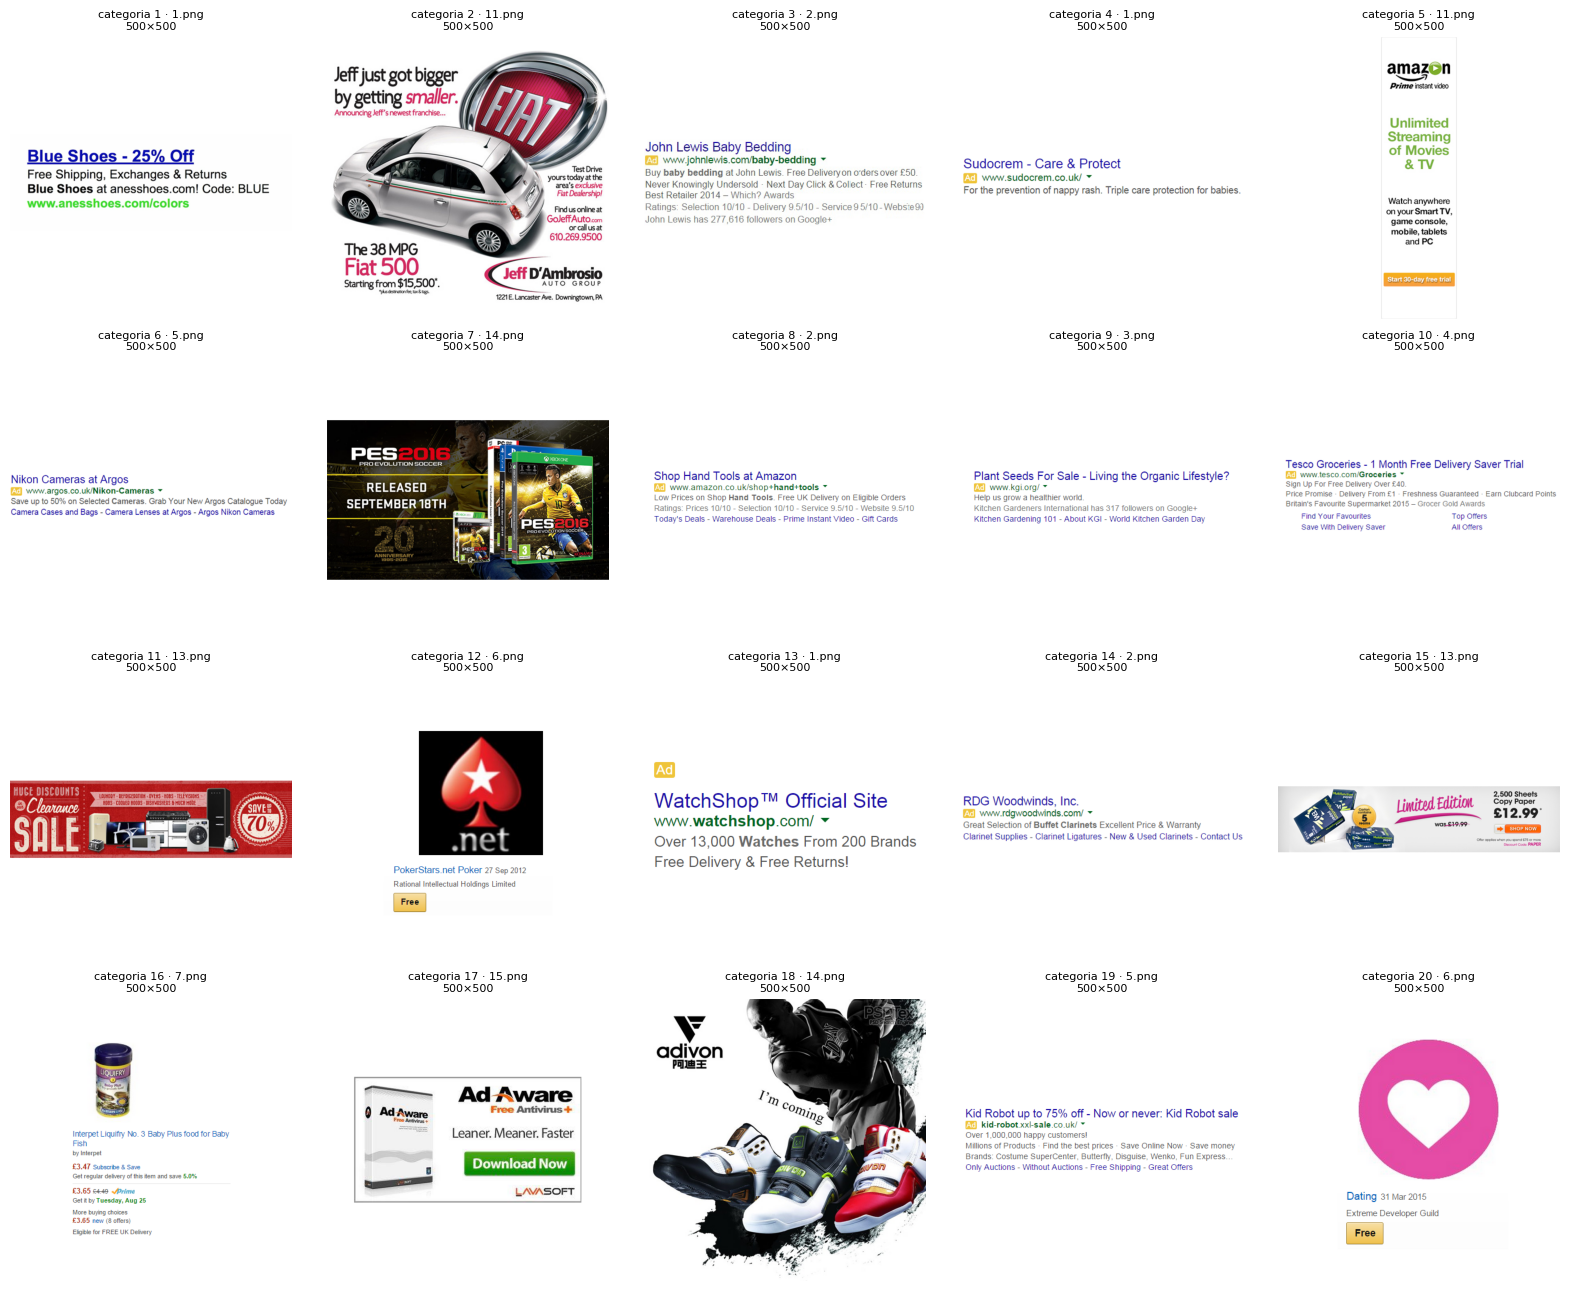

In [9]:
import matplotlib.pyplot as plt

# EDA do corpus, focada no que afeta o CLIP:
# * modo de cor / transparência: tratados em carregar_imagem (fundo branco);
# * proporção: o processor do CLIP redimensiona o menor lado para RESOLUCAO_CLIP e faz center
#   crop quadrado, então o lado maior perde (1 - menor/maior) da sua extensão, metade de cada lado
#   (a perda não depende da resolução);
# * resolução: anúncios de ~500 px são reduzidos para RESOLUCAO_CLIP, e texto pequeno pode ficar ilegível.
print("Modos de cor:", Counter(corpus["modo"]).most_common())
print(f"Com transparência (compostos sobre fundo branco): {int(corpus['transparente'].sum())} anúncios")
display(corpus[["largura", "altura", "proporcao"]].describe().round(2))

print("Tamanhos distintos (largura×altura):")
display((corpus["largura"].astype(str) + "×" + corpus["altura"].astype(str)).value_counts().to_frame("anúncios"))

menor = corpus[["largura", "altura"]].min(axis=1)
maior = corpus[["largura", "altura"]].max(axis=1)
corpus["perda_crop_por_lado"] = (1 - menor / maior) / 2
nao_quadrados = corpus[corpus["largura"] != corpus["altura"]]
print(f"Não quadrados: {len(nao_quadrados)} de {len(corpus)}; perda máxima no center crop: "
      f"{corpus['perda_crop_por_lado'].max():.1%} de cada lado do lado maior")

print(f"Redução de escala no CLIP: ~500 px -> {RESOLUCAO_CLIP} px (fator {RESOLUCAO_CLIP / 500:.2f})")

# Anúncios não quadrados: original × o quadrado central que o CLIP efetivamente vê
if len(nao_quadrados):
    fig, eixos = plt.subplots(len(nao_quadrados), 2, figsize=(8, 4 * len(nao_quadrados)), squeeze=False)
    for k, (_, r) in enumerate(nao_quadrados.iterrows()):
        img = carregar_imagem(r["caminho"])
        lado = min(img.size)
        esq, topo = (img.width - lado) // 2, (img.height - lado) // 2
        eixos[k, 0].imshow(img)
        eixos[k, 0].set_title(f"cat. {r['categoria']} · {r['n']}.png ({img.width}×{img.height})", fontsize=9)
        eixos[k, 1].imshow(img.crop((esq, topo, esq + lado, topo + lado)))
        eixos[k, 1].set_title(f"center crop (perde {r['perda_crop_por_lado']:.1%} de cada lado)", fontsize=9)
    for ax in eixos.flat:
        ax.axis("off")
    plt.tight_layout()
    fig.savefig(DIR_REPORT_ASSETS / "center_crop_nao_quadrados.png", dpi=120)
    plt.show()

# Anúncios com transparência: convert("RGB") direto × composição sobre fundo branco
transp = corpus[corpus["transparente"]]
if len(transp):
    fig, eixos = plt.subplots(2, len(transp), figsize=(2.6 * len(transp), 5.5), squeeze=False)
    for k, (_, r) in enumerate(transp.iterrows()):
        with Image.open(r["caminho"]) as img:
            eixos[0, k].imshow(img.convert("RGB"))
        eixos[1, k].imshow(carregar_imagem(r["caminho"]))
        eixos[0, k].set_title(f"cat. {r['categoria']} · {r['n']}.png ({r['modo']})", fontsize=8)
    eixos[0, 0].set_ylabel('convert("RGB")')
    eixos[1, 0].set_ylabel("fundo branco")
    for ax in eixos.flat:
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()

# Um anúncio sorteado por categoria (diversidade do corpus, R2)
exemplos = corpus.groupby("categoria").sample(n=1, random_state=SEED)
fig, eixos = plt.subplots(4, 5, figsize=(16, 13))
for ax, (_, r) in zip(eixos.flat, exemplos.iterrows()):
    ax.imshow(carregar_imagem(r["caminho"]))
    ax.set_title(f"categoria {r['categoria']} · {r['n']}.png\n{r['largura']}×{r['altura']}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "exemplos_por_categoria.png", dpi=120)
plt.show()

**Corpus usado (R1, R2).** Usei o **corpus inteiro de anúncios: 301 arquivos de `Ads/`, em 20
categorias**.

- **Por que 301 e não 300.** O artigo fala em 300 anúncios (20 × 15); a categoria 1 tem 16 arquivos, e
  o extra é `1/16.png`. Ele não é cópia de nenhum outro (md5: **0 duplicatas exatas**) nem
  quase-duplicata: o anúncio mais parecido com ele (cosseno imagem-imagem) é `6/11.png`, de outra
  categoria, com **0,758**. Por isso foi mantido.
- **R1.** O enunciado aceita o corpus inteiro **ou** um subconjunto de ≥ 500 imagens. O ADS-16 só tem
  301 anúncios, então o corpus inteiro cumpre o R1 pela primeira opção.
- **R2 não se aplica**, porque não há subconjunto a justificar. A grade com um anúncio sorteado por
  categoria (acima) mostra a variedade das 20 categorias.
- **O que ficou de fora.** `Corpus/` (fotos pessoais dos participantes) e `Documents/`. Fotos pessoais
  não são publicidade: não têm logo, texto de marketing nem produto em destaque, e eram cerca de 8 vezes
  mais numerosas que os anúncios (2.697 imagens no total contra 301). Misturadas, dominariam o ranking e
  a busca; a hipótese (não medida) é que conceitos como "a smiling person" subiriam artificialmente.
- **Quase-duplicatas.** Há **7 pares com cosseno imagem-imagem ≥ 0,9** (figura da seção de
  embeddings): `2/1`×`2/5` (0,941), `12/2`×`12/5` (0,926), `2/2`×`2/3` (0,918), `5/1`×`5/2` (0,908),
  `2/1`×`2/4` (0,905), `20/1`×`20/2` (0,905) e `2/4`×`2/5` (0,902). Todos são anúncios só de texto do
  mesmo tema e da mesma categoria: acessórios e peças de carro na 2 (4 pares entre os anúncios 1 a 5),
  sites de slots na 12, DVDs na 5 e sites de namoro na 20. Como
  os textos são diferentes, são anúncios distintos de fato veiculados, e a repetição de campanhas faz
  parte do corpus: **foram mantidos**. A consequência é registrada onde aparece: o par `2/2` × `2/3`
  ocupou 2 das 5 vagas nas buscas 1 e 2.

**O que a EDA mostrou e importa para o CLIP.**
- **Boa parte dos anúncios é só texto**, no estilo de anúncio de buscador (título em azul sobre fundo
  branco), além de banners e fotos de produto. Esse achado explica boa parte do ranking e da busca.
- **Transparência:** 9 arquivos estão em modos que podem ter alfa (5 RGBA, 4 P), mas **nenhum tem pixel
  transparente**. A composição sobre fundo branco em `carregar_imagem` é só preventiva: não muda nenhuma
  imagem deste corpus.
- **Tamanhos:** 298 anúncios têm 500×500; só 1 não é quadrado (600×461), e o center crop do CLIP corta
  11,6% de cada lado dele. O risco maior é a resolução: ~500 px viram 336 px na entrada do modelo.

## Modelo CLIP e embeddings

Nenhum modelo é treinado: o CLIP só gera os embeddings das imagens e dos textos.

**Checkpoint: `openai/clip-vit-large-patch14-336`**, revisão fixada por SHA
(`ce19dc912ca5cd21c8a653c79e251e808ccabcd1`). Por que este:
1. **Resolução 336 px:** os anúncios (~500 px) são reduzidos por um fator 0,67, contra 0,45 nos modelos
   de 224 px. Como boa parte do corpus é texto, isso preserva melhor letras, preços e logos.
2. **Patch 14:** 576 patches por imagem (24 × 24), contra 196 no ViT-B/16 e 49 no ViT-B/32: mais
   detalhe por região.
3. **Custo irrelevante neste corpus:** 428M parâmetros, 1,76 GB de VRAM no carregamento e cerca de 33 s
   para os 301 anúncios na T4. Diferente da A1, a escolha pôde ser por qualidade, não por custo.
4. **É o CLIP original da OpenAI**, o do artigo, coerente com a discussão do pré-treino contrastivo (R13).

**Decisões de execução.**
- **fp32:** cabe com folga; fp16 pode mudar o cosseno na terceira casa decimal, justamente na faixa do
  threshold.
- **Processor do mesmo checkpoint e revisão** (resize, center crop 336 e normalização com a média e o
  desvio do pré-treino do CLIP), conferido por `assert` (`projection_dim`, `crop_size`, shape de entrada).
- **Embedding usado:** no transformers 5, `get_image_features` devolve um objeto. O embedding projetado
  é o `pooler_output` (1, 768); o `last_hidden_state` (1, 577, 1024) não passou pela projeção (output da
  célula de carregamento).

**Reprodutibilidade dos pesos.** O commit fixado só tem `pytorch_model.bin`; o `model.safetensors`
existe apenas em pull requests de um robô de conversão, fora do commit. Por isso `use_safetensors=True`
dá erro com a revisão fixada. Sem ele, o transformers carrega o `.bin` do commit e, em segundo plano,
baixaria o `.safetensors` de um desses PRs (+1,7 GB, sem uso). A variável
`DISABLE_SAFETENSORS_CONVERSION` desliga esse download: **os pesos usados são os do SHA fixado**. O aviso
sobre `HF_TOKEN` é inofensivo, porque o modelo é público.

In [10]:
import torch

from src.clip_busca import carregar_clip

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def pico_vram_etapa() -> dict:
    """Picos de VRAM (GB) desde o último reset_peak_memory_stats: alocada (tensores do PyTorch) e
    reservada (inclui o cache do alocador; mais perto do nvidia-smi). Vazio na CPU."""
    if DEVICE != "cuda":
        return {}
    return {"pico_vram_gb": round(torch.cuda.max_memory_allocated() / 1e9, 2),
            "pico_vram_reservada_gb": round(torch.cuda.max_memory_reserved() / 1e9, 2)}


# Modelo e processor do MESMO checkpoint e revisão, fp32, eval (detalhes e o porquê de cada escolha,
# inclusive o DISABLE_SAFETENSORS_CONVERSION, na docstring de src/clip_busca.carregar_clip).
if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()
_t0 = time.perf_counter()
modelo, processor = carregar_clip(CHECKPOINT_CLIP, REVISAO_CLIP, DEVICE)
TEMPOS.append({"etapa": "carregamento do CLIP", "segundos": round(time.perf_counter() - _t0, 1),
               **pico_vram_etapa()})

# Verificações: checkpoint e processor são os esperados
crop = processor.image_processor.crop_size
pixels = processor(images=[carregar_imagem(corpus["caminho"].iloc[0])], return_tensors="pt")["pixel_values"]
assert modelo.config.projection_dim == DIM_EMBEDDING, modelo.config.projection_dim
assert (crop["height"], crop["width"]) == (RESOLUCAO_CLIP, RESOLUCAO_CLIP), crop
assert tuple(pixels.shape) == (1, 3, RESOLUCAO_CLIP, RESOLUCAO_CLIP), tuple(pixels.shape)

n_parametros = sum(p.numel() for p in modelo.parameters())
print(f"{CHECKPOINT_CLIP}@{REVISAO_CLIP[:7]} em {DEVICE}: {n_parametros / 1e6:.0f}M parâmetros, "
      f"entrada {tuple(pixels.shape)}, embedding de {DIM_EMBEDDING} dimensões")

# O que get_image_features devolve no transformers 5: um objeto, não um tensor
with torch.inference_mode():
    saida = modelo.get_image_features(pixel_values=pixels.to(DEVICE))
print(type(saida).__name__, {k: tuple(v.shape) for k, v in saida.items() if v is not None})
if DEVICE == "cuda":
    print(f"Pico de VRAM: alocada {TEMPOS[-1]['pico_vram_gb']} GB, reservada {TEMPOS[-1]['pico_vram_reservada_gb']} GB")

config.json:   0%|          | 0.00/4.76k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.71GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

openai/clip-vit-large-patch14-336@ce19dc9 em cuda: 428M parâmetros, entrada (1, 3, 336, 336), embedding de 768 dimensões
BaseModelOutputWithPooling {'last_hidden_state': (1, 577, 1024), 'pooler_output': (1, 768)}
Pico de VRAM: alocada 1.71 GB, reservada 1.76 GB


In [11]:
from functools import partial

import torch.nn.functional as F

from src import clip_busca

# Embeddings L2-normalizados (CPU, fp32), com o modelo e o processor já carregados:
# * embeddings_imagens(caminhos): em lotes de TAMANHO_LOTE, via carregar_imagem (fundo branco);
# * embeddings_textos(textos): padding até a frase mais longa do lote + attention_mask (R14).
# Por dentro, o embedding é o pooler_output (projetado, DIM_EMBEDDING dimensões), não o
# last_hidden_state (ver src/clip_busca._projecao).
embeddings_imagens = partial(clip_busca.embeddings_imagens, modelo, processor, tamanho_lote=TAMANHO_LOTE)
embeddings_textos = partial(clip_busca.embeddings_textos, modelo, processor)

Embeddings: (301, 768) em 33.9 s; VRAM 2.98 GB alocada / 3.38 GB reservada
Pares com cosseno imagem-imagem >= 0.9: 7
  2/1.png × 2/5.png: cosseno 0.941
  12/2.png × 12/5.png: cosseno 0.926
  2/2.png × 2/3.png: cosseno 0.918
  5/1.png × 5/2.png: cosseno 0.908
  2/1.png × 2/4.png: cosseno 0.905
  20/1.png × 20/2.png: cosseno 0.905
  2/4.png × 2/5.png: cosseno 0.902
Cosseno imagem-imagem (pares distintos): mediana 0.488 · P95 0.717 · máx 0.941
Vizinho do 1/16.png: ADS16_Benchmark_part1/ADS16_Benchmark_part1/Ads/Ads/6/11.png (cosseno 0.758)


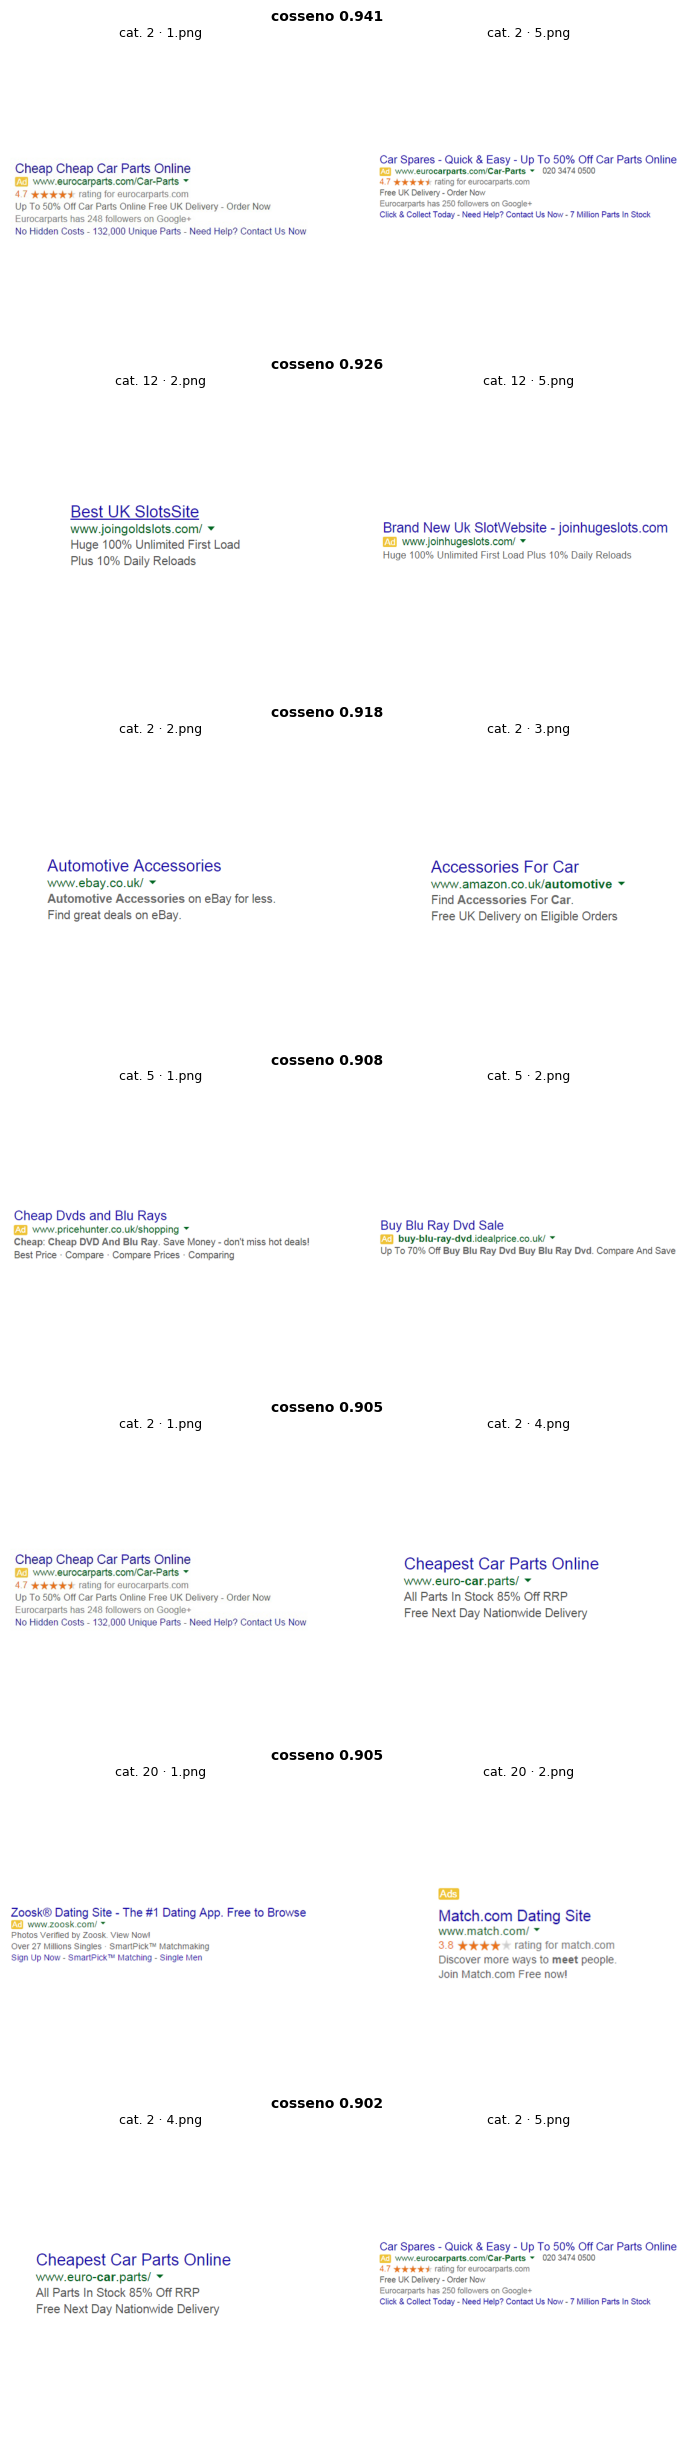

In [12]:
import numpy as np
# Embeddings normalizados das 301 imagens do corpus (só inferência, nenhum treino)
assert carregar_imagem.__module__ == "src.dados", carregar_imagem.__module__  # a função do src, com fundo branco

if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()
_t0 = time.perf_counter()
EMB_IMAGENS = embeddings_imagens(corpus["caminho"].tolist())
TEMPOS.append({"etapa": "embeddings das imagens", "segundos": round(time.perf_counter() - _t0, 1),
               **pico_vram_etapa()})

assert EMB_IMAGENS.shape == (len(corpus), DIM_EMBEDDING), tuple(EMB_IMAGENS.shape)
assert torch.allclose(EMB_IMAGENS.norm(dim=-1), torch.ones(len(corpus)), atol=1e-4)  # norma 1: produto = cosseno
print(f"Embeddings: {tuple(EMB_IMAGENS.shape)} em {TEMPOS[-1]['segundos']} s; "
      f"VRAM {TEMPOS[-1].get('pico_vram_gb')} GB alocada / {TEMPOS[-1].get('pico_vram_reservada_gb')} GB reservada")

torch.save({"checkpoint": CHECKPOINT_CLIP, "revisao": REVISAO_CLIP,
            "caminho_rel": corpus["caminho_rel"].tolist(), "embeddings": EMB_IMAGENS},
           DIR_OUTPUTS / "embeddings_imagens.pt")

# Quase-duplicatas: o md5 só pega cópias exatas. Cosseno imagem-imagem entre todos os pares; os pares
# acima do limiar são mostrados lado a lado para inspeção visual (a decisão de manter ou remover é
# registrada no markdown do corpus). Também: o vizinho mais próximo do 1/16.png (arquivo extra da cat. 1).
LIMIAR_QUASE_DUPLICATA = 0.9
sim_ii = EMB_IMAGENS @ EMB_IMAGENS.T
sim_ii.fill_diagonal_(-1)
PARES_QUASE_DUPLICATAS = [tuple(par) for par in
                          (torch.triu(sim_ii, diagonal=1) >= LIMIAR_QUASE_DUPLICATA).nonzero().tolist()]
print(f"Pares com cosseno imagem-imagem >= {LIMIAR_QUASE_DUPLICATA}: {len(PARES_QUASE_DUPLICATAS)}")


def nome_anuncio(idx: int) -> str:
    """'cat/n.png' de uma posição do corpus (os índices de tensor não dizem nada ao leitor)."""
    return f"{corpus['categoria'].iloc[idx]}/{corpus['n'].iloc[idx]}.png"


for a, b in sorted(PARES_QUASE_DUPLICATAS, key=lambda par: -float(sim_ii[par])):
    print(f"  {nome_anuncio(a)} × {nome_anuncio(b)}: cosseno {sim_ii[a, b]:.3f}")

# Números para o R12: imagem-imagem típico (todos os pares distintos, fora da diagonal)
cos_ii = sim_ii[torch.triu(torch.ones_like(sim_ii, dtype=torch.bool), diagonal=1)].numpy()
print(f"Cosseno imagem-imagem (pares distintos): mediana {np.median(cos_ii):.3f} · P95 "
      f"{np.percentile(cos_ii, 95):.3f} · máx {cos_ii.max():.3f}")
k = corpus.index[(corpus["categoria"] == 1) & (corpus["n"] == 16)][0]
v = int(sim_ii[k].argmax())
print(f"Vizinho do 1/16.png: {corpus['caminho_rel'][v]} (cosseno {sim_ii[k, v]:.3f})")

pares_mostrados = sorted(PARES_QUASE_DUPLICATAS, key=lambda par: -float(sim_ii[par]))[:10]  # no máximo 10
if pares_mostrados:
    fig, eixos = plt.subplots(len(pares_mostrados), 2, figsize=(7, 3.5 * len(pares_mostrados)), squeeze=False)
    for linha, (a, b) in enumerate(pares_mostrados):
        for coluna, idx in enumerate((a, b)):
            r = corpus.iloc[idx]
            eixos[linha, coluna].imshow(carregar_imagem(r["caminho"]))
            eixos[linha, coluna].set_title(f"cat. {r['categoria']} · {r['n']}.png", fontsize=9)
            eixos[linha, coluna].axis("off")
        eixos[linha, 0].text(1.05, 1.08, f"cosseno {sim_ii[a, b]:.3f}", transform=eixos[linha, 0].transAxes,
                             ha="center", fontsize=10, fontweight="bold")
    plt.tight_layout()
    fig.savefig(DIR_REPORT_ASSETS / "quase_duplicatas.png", dpi=120)
    plt.show()

## 2.1 — Ranking de objetos por frequência semântica

### Descrições de objetos/conceitos (R3)

**25 conceitos**, em três grupos: objetos e produtos (13), pessoas e cenários (5) e elementos de design
e marketing (7). Critérios:
- **Um conceito por frase.** O codificador de texto do CLIP não faz "ou" lógico: "A or B" vira um vetor
  no meio dos dois, que pode não ficar perto de nenhum. Por isso "bold text and brand logo" virou dois
  conceitos, "large bold text" e "a brand logo", que podem ser medidos separadamente.
- **Sem quase-sinônimos**, que disputariam a mesma região do espaço e distorceriam o ranking.
- **Com artigo e em inglês**, como nas legendas do pré-treino (o CLIP da OpenAI foi treinado quase só
  com texto em inglês).

**Prompt ensembling** (Radford et al., 2021, seção 3.1.4): cada conceito é a média dos embeddings em 4
templates genéricos ("a photo of {}.", "an advertisement showing {}.", "an image containing {}." e o
conceito puro), renormalizada para continuar sendo cosseno. Os templates servem para qualquer conceito
da lista: um template específico, como "a product shot of {}", puxaria todos os conceitos para "foto de
produto" e mudaria o ranking pela forma de escrever, não pelo corpus.

In [13]:
import numpy as np
import pandas as pd

# Conceitos (R3): objetos concretos, pessoas/cenários e elementos de design/marketing de anúncios.
# Critérios: um conceito por frase (o CLIP não faz "ou" lógico: "A or B" vira um vetor no meio dos
# dois, que pode não ficar perto de nenhum), sem quase-sinônimos, com artigo (como nas legendas do
# pré-treino) e em inglês (o CLIP da OpenAI foi treinado quase só com texto em inglês).
CONCEITOS = [
    # Objetos / produtos
    "a car", "a smartphone", "a laptop computer", "a perfume bottle", "a makeup product",
    "a plate of food", "a beverage can", "a pair of shoes", "fashion clothing", "a wrist watch",
    "a house", "furniture", "a credit card",
    # Pessoas e cenários
    "a smiling person", "a group of people", "a child", "an outdoor landscape", "an office",
    # Elementos de design e marketing
    "large bold text", "a brand logo", "a discount price tag", "social media icons",
    "a plain solid color background", "a futuristic technology background", "a hand holding a product",
]
assert len(CONCEITOS) >= 20 and len(set(CONCEITOS)) == len(CONCEITOS)

# Prompt ensembling (Radford et al., 2021, seção 3.1.4): média dos embeddings do mesmo conceito em
# vários templates, renormalizada (continua sendo cosseno). Templates genéricos, que fazem sentido
# para qualquer conceito da lista: um template específico ("a product shot of {}") puxaria todos os
# conceitos para "foto de produto" e mudaria o ranking pela forma de escrever, não pelo corpus.
TEMPLATES = ["a photo of {}.", "an advertisement showing {}.", "an image containing {}.", "{}"]


def obter_embeddings_conceitos(conceitos, templates) -> torch.Tensor:
    """(N, DIM_EMBEDDING): média dos embeddings dos templates de cada conceito, renormalizada."""
    medias = [embeddings_textos([t.format(c) for t in templates]).mean(dim=0) for c in conceitos]
    return F.normalize(torch.stack(medias), dim=-1)


_t0 = time.perf_counter()
EMB_CONCEITOS = obter_embeddings_conceitos(CONCEITOS, TEMPLATES)
TEMPOS.append({"etapa": "embeddings dos conceitos", "segundos": round(time.perf_counter() - _t0, 1)})
assert EMB_CONCEITOS.shape == (len(CONCEITOS), DIM_EMBEDDING), tuple(EMB_CONCEITOS.shape)
print(f"{len(CONCEITOS)} conceitos × {len(TEMPLATES)} templates -> embeddings {tuple(EMB_CONCEITOS.shape)}")

25 conceitos × 4 templates -> embeddings (25, 768)


In [14]:
# Cosseno imagem × conceito: os dois lados têm norma 1, então o produto interno é o cosseno.
MATRIZ_SIMILARIDADE = EMB_IMAGENS @ EMB_CONCEITOS.T   # (301 imagens, N conceitos)
assert MATRIZ_SIMILARIDADE.shape == (len(corpus), len(CONCEITOS))
S = MATRIZ_SIMILARIDADE.numpy()
print(f"Matriz imagens × conceitos: {S.shape}; cosseno de {S.min():.3f} a {S.max():.3f}")

Matriz imagens × conceitos: (301, 25); cosseno de 0.034 a 0.249


### Threshold de similaridade (R4, R5)

**Threshold: 0,17**, aproximadamente o percentil 85 de todas as similaridades imagem × conceito
(P85 = 0,171): **1.186 de 7.525 pares (15,8%)** ficam acima. Um conceito "ocorre" num anúncio quando o
cosseno é ≥ 0,17, e uma imagem pode ter vários conceitos ao mesmo tempo (multi-rótulo). Por isso não há
softmax entre os conceitos: ele obrigaria cada imagem a ter um único rótulo e somaria 1 mesmo quando
nenhum conceito se aplica.

**Por que vem da distribuição.** O cosseno imagem-texto do CLIP vive numa faixa estreita e baixa:
aqui, de **0,034 a 0,249**, com mediana **0,137** e P95 **0,199**. Um corte "intuitivo" como 0,5 daria
frequência zero para tudo.

**Evidências (células abaixo).**
- **Sensibilidade:** o top-5 é o mesmo, na mesma ordem, de 0,15 a 0,19. As contagens, porém, mudam
  bastante com o corte (tabela de frequência por threshold).
- **Essa estabilidade não prova que o corte está certo.** A ordem por frequência é quase a mesma da
  ordem pela similaridade média, e os dois primeiros conceitos têm a **média do corpus acima do próprio
  corte** ("large bold text" 0,194, "a discount price tag" 0,190). O boxplot mostra medianas que vão de
  ~0,10 ("a plate of food") a ~0,19: com um corte global, a frequência mede em boa parte a afinidade de
  base de cada frase com qualquer anúncio.
- **Fronteira:** para os 3 conceitos mais frequentes, os anúncios logo abaixo e logo acima do corte são
  do mesmo tipo (anúncios com texto e produto). O corte **não separa** presença de ausência para esses
  conceitos de layout. Em "a discount price tag", por exemplo, ficam acima do corte um banner do
  McDonald's e um jogador de futebol, sem preço nenhum.
- **Template:** com um único template neutro ("a photo of {}."), a média cai entre 0,01 e 0,03 em todos
  os conceitos, o mesmo tamanho da janela de ±0,02. O threshold vale para o ensemble escolhido.

**Alternativa considerada e limitação.** Um corte por conceito (por exemplo, z-score) compararia cada
conceito com ele mesmo e mediria "incomumente X para este corpus", mas subcontaria um conceito que é
de fato onipresente, como texto em anúncios. Mantive o corte global, simples e transparente, e declaro
a limitação: para conceitos de layout, a frequência é uma medida de afinidade, não uma contagem de
presença.

Percentis do cosseno (todos os pares): 50% 0.137 · 85% 0.171 · 95% 0.199
Pares acima do threshold 0.17: 1186 de 7525 (15.8%)


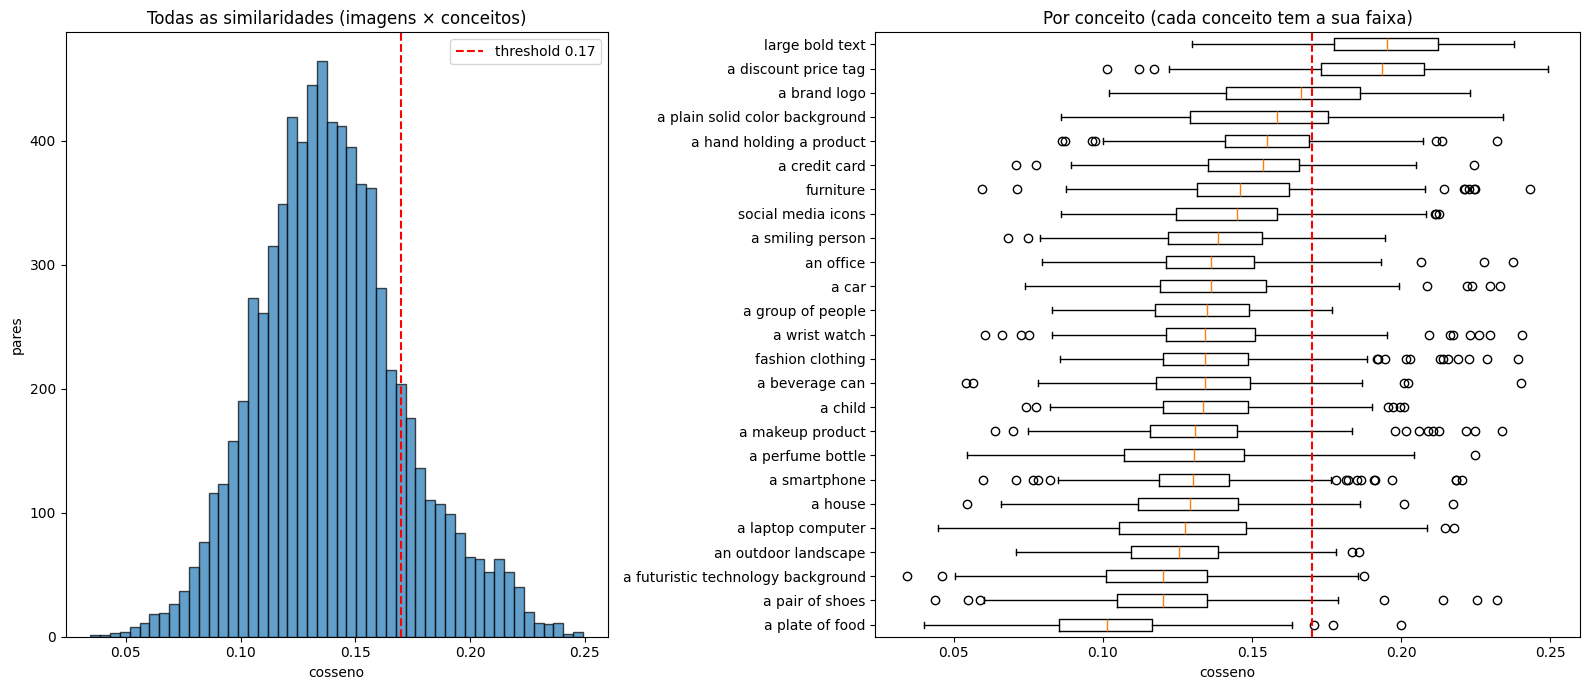

,t = 0.15,t = 0.16,t = 0.17,t = 0.18,t = 0.19
1,large bold text,large bold text,large bold text,large bold text,large bold text
2,a discount price tag,a discount price tag,a discount price tag,a discount price tag,a discount price tag
3,a brand logo,a brand logo,a brand logo,a brand logo,a brand logo
4,a plain solid color background,a plain solid color background,a plain solid color background,a plain solid color background,a plain solid color background
5,a hand holding a product,a hand holding a product,a hand holding a product,a hand holding a product,a hand holding a product


,t = 0.15,t = 0.16,t = 0.17,t = 0.18,t = 0.19
large bold text,299,280,255,214,167
a discount price tag,277,263,237,203,167
a brand logo,197,169,136,94,49
a plain solid color background,179,145,97,61,34
a hand holding a product,173,110,72,32,16
a credit card,168,106,51,27,12
furniture,130,85,48,23,15
social media icons,118,71,38,19,13
a car,92,50,24,14,10
a laptop computer,63,36,24,14,6


In [15]:
# Threshold (R4, R5). O cosseno imagem-texto do CLIP fica numa faixa estreita e baixa, então o corte
# vem da distribuição observada, não de um número redondo. Evidências:
# (1) distribuição global e por conceito; (2) sensibilidade do top-5 ao threshold;
# (3) anúncios logo acima e logo abaixo do corte (célula seguinte).
# Sem softmax entre conceitos: ele força um rótulo por imagem (soma 1 mesmo se nenhum conceito se
# aplica), e "objetos que ocorrem" é multi-rótulo.
THRESHOLD = 0.17  # decisão a justificar no markdown com as evidências abaixo

print(f"Percentis do cosseno (todos os pares): 50% {np.percentile(S, 50):.3f} · 85% {np.percentile(S, 85):.3f}"
      f" · 95% {np.percentile(S, 95):.3f}")
print(f"Pares acima do threshold {THRESHOLD}: {(S >= THRESHOLD).sum()} de {S.size} ({(S >= THRESHOLD).mean():.1%})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1, 1.3]})
ax1.hist(S.ravel(), bins=50, edgecolor="black", alpha=0.7)
ax1.axvline(THRESHOLD, color="red", ls="--", label=f"threshold {THRESHOLD}")
ax1.set(title="Todas as similaridades (imagens × conceitos)", xlabel="cosseno", ylabel="pares")
ax1.legend()
ordem = np.argsort(np.median(S, axis=0))
ax2.boxplot([S[:, j] for j in ordem], vert=False, tick_labels=[CONCEITOS[j] for j in ordem])
ax2.axvline(THRESHOLD, color="red", ls="--")
ax2.set(title="Por conceito (cada conceito tem a sua faixa)", xlabel="cosseno")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "distribuicao_similaridades.png", dpi=150)
plt.show()


def top_k_frequencia(threshold: float, k: int = 5) -> list:
    """Os k conceitos mais frequentes (cosseno >= threshold); desempate pela similaridade média."""
    freq = (S >= threshold).sum(axis=0)
    return [CONCEITOS[j] for j in np.lexsort((-S.mean(axis=0), -freq))[:k]]


# Sensibilidade: o top-5 por frequência muda se o threshold variar?
variacoes = np.round(THRESHOLD + np.array([-0.02, -0.01, 0.0, 0.01, 0.02]), 3)
sensibilidade = pd.DataFrame({f"t = {t}": top_k_frequencia(t) for t in variacoes}, index=range(1, 6))
display(sensibilidade)

# ... e as contagens: a ordem pode ser estável enquanto a magnitude muda muito
freq_por_t = pd.DataFrame({f"t = {t}": (S >= t).sum(axis=0) for t in variacoes}, index=CONCEITOS)
display(freq_por_t.sort_values(freq_por_t.columns[2], ascending=False))  # coluna do threshold escolhido

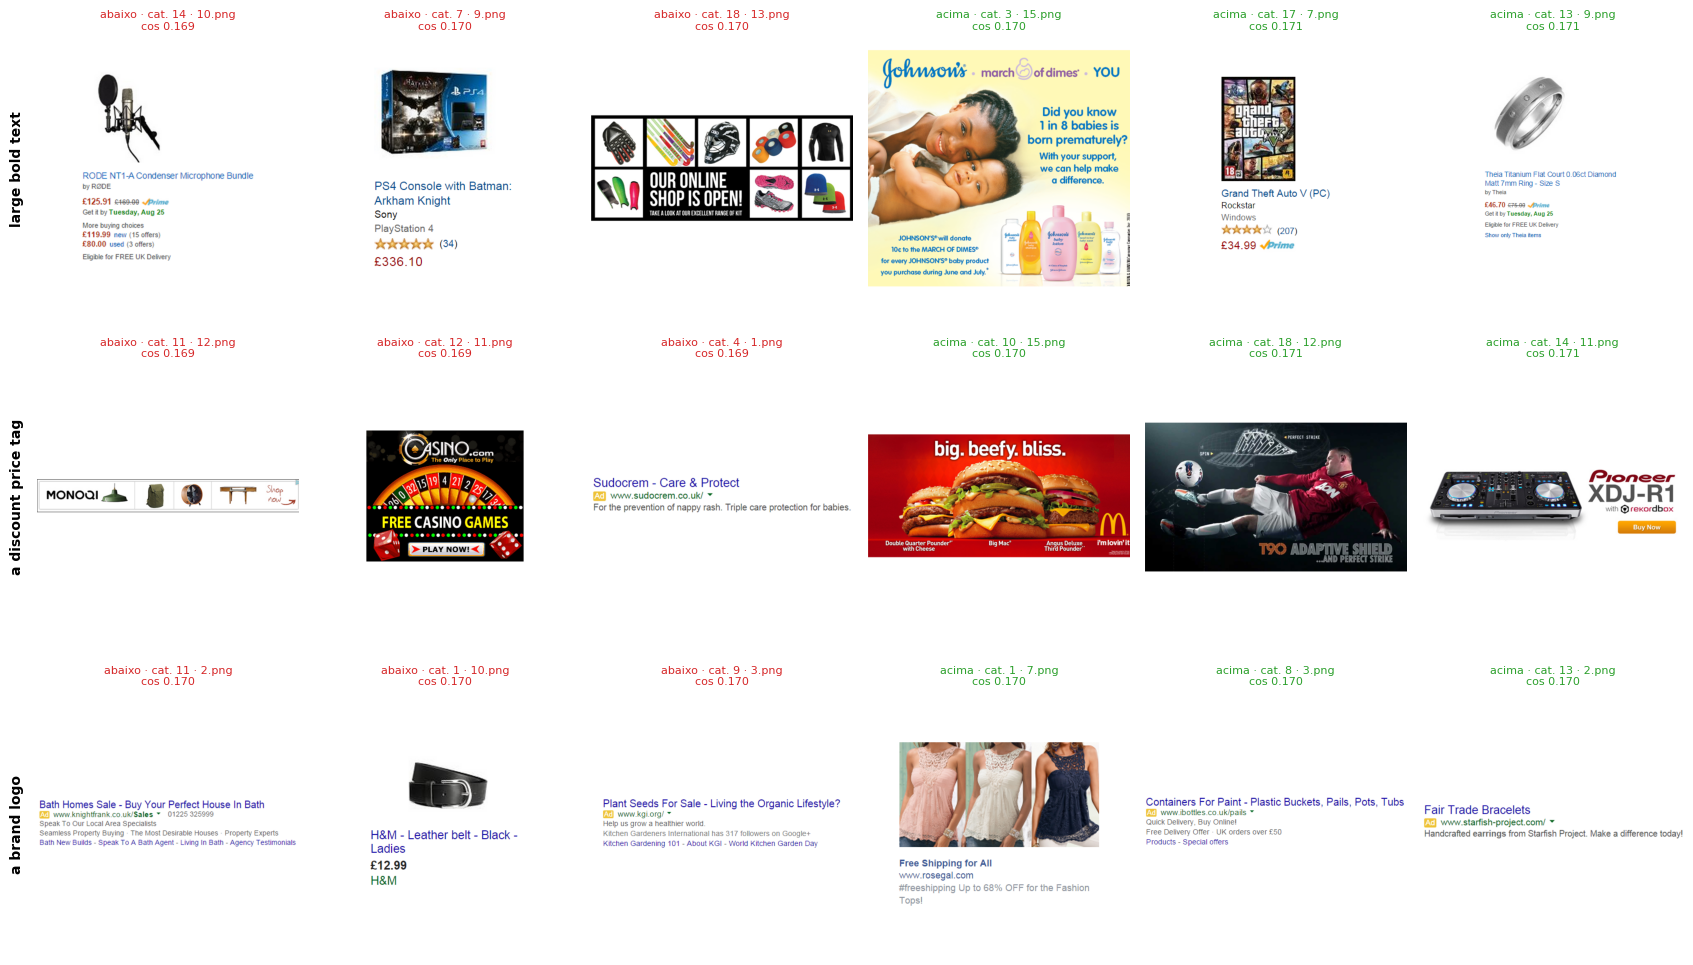

In [16]:
# Casos na fronteira (R5): para os 3 conceitos mais frequentes, os 3 anúncios logo abaixo e os 3 logo
# acima do threshold. Se o corte separa bem presença de ausência, os de cima mostram o conceito e os
# de baixo não.
CONCEITOS_FRONTEIRA = top_k_frequencia(THRESHOLD, k=3)
fig, eixos = plt.subplots(len(CONCEITOS_FRONTEIRA), 6, figsize=(17, 3.4 * len(CONCEITOS_FRONTEIRA)), squeeze=False)
for i, conceito in enumerate(CONCEITOS_FRONTEIRA):
    s = S[:, CONCEITOS.index(conceito)]
    abaixo = np.where(s < THRESHOLD)[0]
    acima = np.where(s >= THRESHOLD)[0]
    abaixo = abaixo[np.argsort(s[abaixo])][-3:]   # os 3 maiores abaixo do corte (em ordem crescente)
    acima = acima[np.argsort(s[acima])][:3]       # os 3 menores acima do corte
    for k, (idx, lado) in enumerate([(a, "abaixo") for a in abaixo] + [(a, "acima") for a in acima]):
        r = corpus.iloc[idx]
        ax = eixos[i, k]
        ax.imshow(carregar_imagem(r["caminho"]))
        ax.set_title(f"{lado} · cat. {r['categoria']} · {r['n']}.png\ncos {s[idx]:.3f}", fontsize=8,
                     color="tab:green" if lado == "acima" else "tab:red")
        ax.axis("off")
    eixos[i, 0].text(-0.05, 0.5, conceito, transform=eixos[i, 0].transAxes, rotation=90,
                     ha="right", va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "threshold_fronteira.png", dpi=120)
plt.show()

### Ranking (R6)

Ordenado pela **frequência** (nº de anúncios com cosseno ≥ threshold), como pede o enunciado, com
desempate pela similaridade média. Duas médias, porque medem coisas diferentes:
- **`sim_media_corpus`:** média sobre os 301 anúncios, a "afinidade de base" da frase com qualquer
  anúncio;
- **`sim_media_acima`:** média só nos anúncios acima do threshold, a força do conceito quando ele ocorre.

In [17]:
# Ranking (R6): ordenado pela frequência (nº de anúncios com cosseno >= THRESHOLD), como pede o
# enunciado; desempate pela similaridade média. Duas médias, porque medem coisas diferentes:
# * sim_media_corpus: média sobre os 301 anúncios ("afinidade de base" da frase com qualquer anúncio);
# * sim_media_acima: média só nos anúncios acima do threshold (força quando o conceito ocorre).
acima = S >= THRESHOLD
COL_FREQ = f"freq (cos >= {THRESHOLD})"
df_ranking = pd.DataFrame({
    "conceito": CONCEITOS,
    COL_FREQ: acima.sum(axis=0),
    "freq_%": 100 * acima.mean(axis=0),
    "sim_media_corpus": S.mean(axis=0),
    "sim_media_acima": [S[acima[:, j], j].mean() if acima[:, j].any() else np.nan for j in range(len(CONCEITOS))],
}).sort_values([COL_FREQ, "sim_media_corpus"], ascending=False).reset_index(drop=True)
df_ranking.index += 1
df_ranking.to_csv(DIR_REPORT_ASSETS / "ranking_frequencia_semantica.csv", index_label="posicao")
display(df_ranking.round(3))

,conceito,freq (cos >= 0.17),freq_%,sim_media_corpus,sim_media_acima
1,large bold text,255,84.718,0.194,0.200
2,a discount price tag,237,78.738,0.190,0.200
3,a brand logo,136,45.183,0.162,0.187
4,a plain solid color background,97,32.226,0.153,0.187
5,a hand holding a product,72,23.920,0.154,0.183
6,a credit card,51,16.944,0.150,0.183
7,furniture,48,15.947,0.148,0.188
8,social media icons,38,12.625,0.143,0.184
9,a car,24,7.973,0.138,0.191
10,a laptop computer,24,7.973,0.127,0.185


In [18]:
# Pureza por categoria (evidência sem rótulos, nenhum treino): dos anúncios acima do threshold de cada
# conceito, quantos estão na categoria mais comum? Um objeto concreto que capta o produto concentra os
# positivos em 1 categoria (15 anúncios); um conceito de layout se espalha por muitas.
linhas_pureza = []
for j, conceito in enumerate(CONCEITOS):
    cats = corpus.loc[S[:, j] >= THRESHOLD, "categoria"]
    if len(cats):
        moda = cats.value_counts()
        linhas_pureza.append({"conceito": conceito, "positivos": len(cats), "categorias": cats.nunique(),
                              "categoria_mais_comum": moda.index[0], "na_mais_comum": int(moda.iloc[0]),
                              "pureza": moda.iloc[0] / len(cats)})
df_pureza = pd.DataFrame(linhas_pureza).sort_values("pureza", ascending=False).reset_index(drop=True)
df_pureza.to_csv(DIR_REPORT_ASSETS / "pureza_por_categoria.csv", index=False)
display(df_pureza.round(2))

,conceito,positivos,categorias,categoria_mais_comum,na_mais_comum,pureza
0,a plate of food,3,2,10,2,0.67
1,a car,24,8,2,14,0.58
2,fashion clothing,23,6,1,13,0.57
3,a smartphone,14,6,6,7,0.50
4,a makeup product,20,7,4,10,0.50
5,a group of people,8,4,20,4,0.50
6,an outdoor landscape,8,5,9,4,0.50
7,a house,10,6,11,5,0.50
8,a pair of shoes,9,4,1,4,0.44
9,a futuristic technology background,7,4,6,3,0.43


In [19]:
# Sensibilidade ao template: o ranking mede o corpus ou a forma como as frases foram escritas?
# Para cada conceito, a sobreposição entre os 15 anúncios mais similares (15 = tamanho de uma
# categoria) com o ensemble de templates e com um único template neutro ("a photo of {}.").
# Sobreposição alta = o conceito aponta para os mesmos anúncios, independentemente do template.
emb_neutro = embeddings_textos([f"a photo of {c}." for c in CONCEITOS])
S_neutro = (EMB_IMAGENS @ emb_neutro.T).numpy()
K_SOBREPOSICAO = 15
sobreposicao = [len(set(np.argsort(S[:, j])[-K_SOBREPOSICAO:]) & set(np.argsort(S_neutro[:, j])[-K_SOBREPOSICAO:]))
                / K_SOBREPOSICAO for j in range(len(CONCEITOS))]
# A sobreposição do top-15 só olha o topo; a frequência e o Jaccard dos conjuntos acima do threshold
# mostram o efeito no que o ranking conta (o threshold foi escolhido para o ensemble).
acima_neutro = S_neutro >= THRESHOLD
jaccard = [((acima[:, j] & acima_neutro[:, j]).sum() / max((acima[:, j] | acima_neutro[:, j]).sum(), 1))
           for j in range(len(CONCEITOS))]
df_template = pd.DataFrame({"conceito": CONCEITOS, f"sobreposição top-{K_SOBREPOSICAO}": sobreposicao,
                            "sim_media_ensemble": S.mean(axis=0), "sim_media_neutro": S_neutro.mean(axis=0),
                            "freq_ensemble": acima.sum(axis=0), "freq_neutro": acima_neutro.sum(axis=0),
                            "jaccard_acima": jaccard})
display(df_template.sort_values(f"sobreposição top-{K_SOBREPOSICAO}").round(3))

,conceito,sobreposição top-15,sim_media_ensemble,sim_media_neutro,freq_ensemble,freq_neutro,jaccard_acima
23,a futuristic technology background,0.467,0.118,0.115,7,1,0.143
5,a plate of food,0.600,0.101,0.087,3,1,0.333
19,a brand logo,0.600,0.162,0.160,136,118,0.776
9,a wrist watch,0.667,0.135,0.124,19,13,0.455
24,a hand holding a product,0.667,0.154,0.140,72,27,0.356
18,large bold text,0.667,0.194,0.182,255,224,0.842
14,a group of people,0.667,0.134,0.114,8,0,0.000
0,a car,0.733,0.138,0.110,24,7,0.292
4,a makeup product,0.733,0.131,0.114,20,10,0.500
12,a credit card,0.733,0.150,0.134,51,16,0.314


### Os 5 objetos mais encontrados (R7)

Para cada um dos 5 conceitos mais frequentes: os 4 anúncios de maior similaridade e 1 anúncio **na
fronteira** (o de menor similaridade que ainda conta para a frequência). O caso mais fraco mostra melhor
do que o mais forte se a frequência é confiável.

Os 5 conceitos mais frequentes: ['large bold text', 'a discount price tag', 'a brand logo', 'a plain solid color background', 'a hand holding a product']


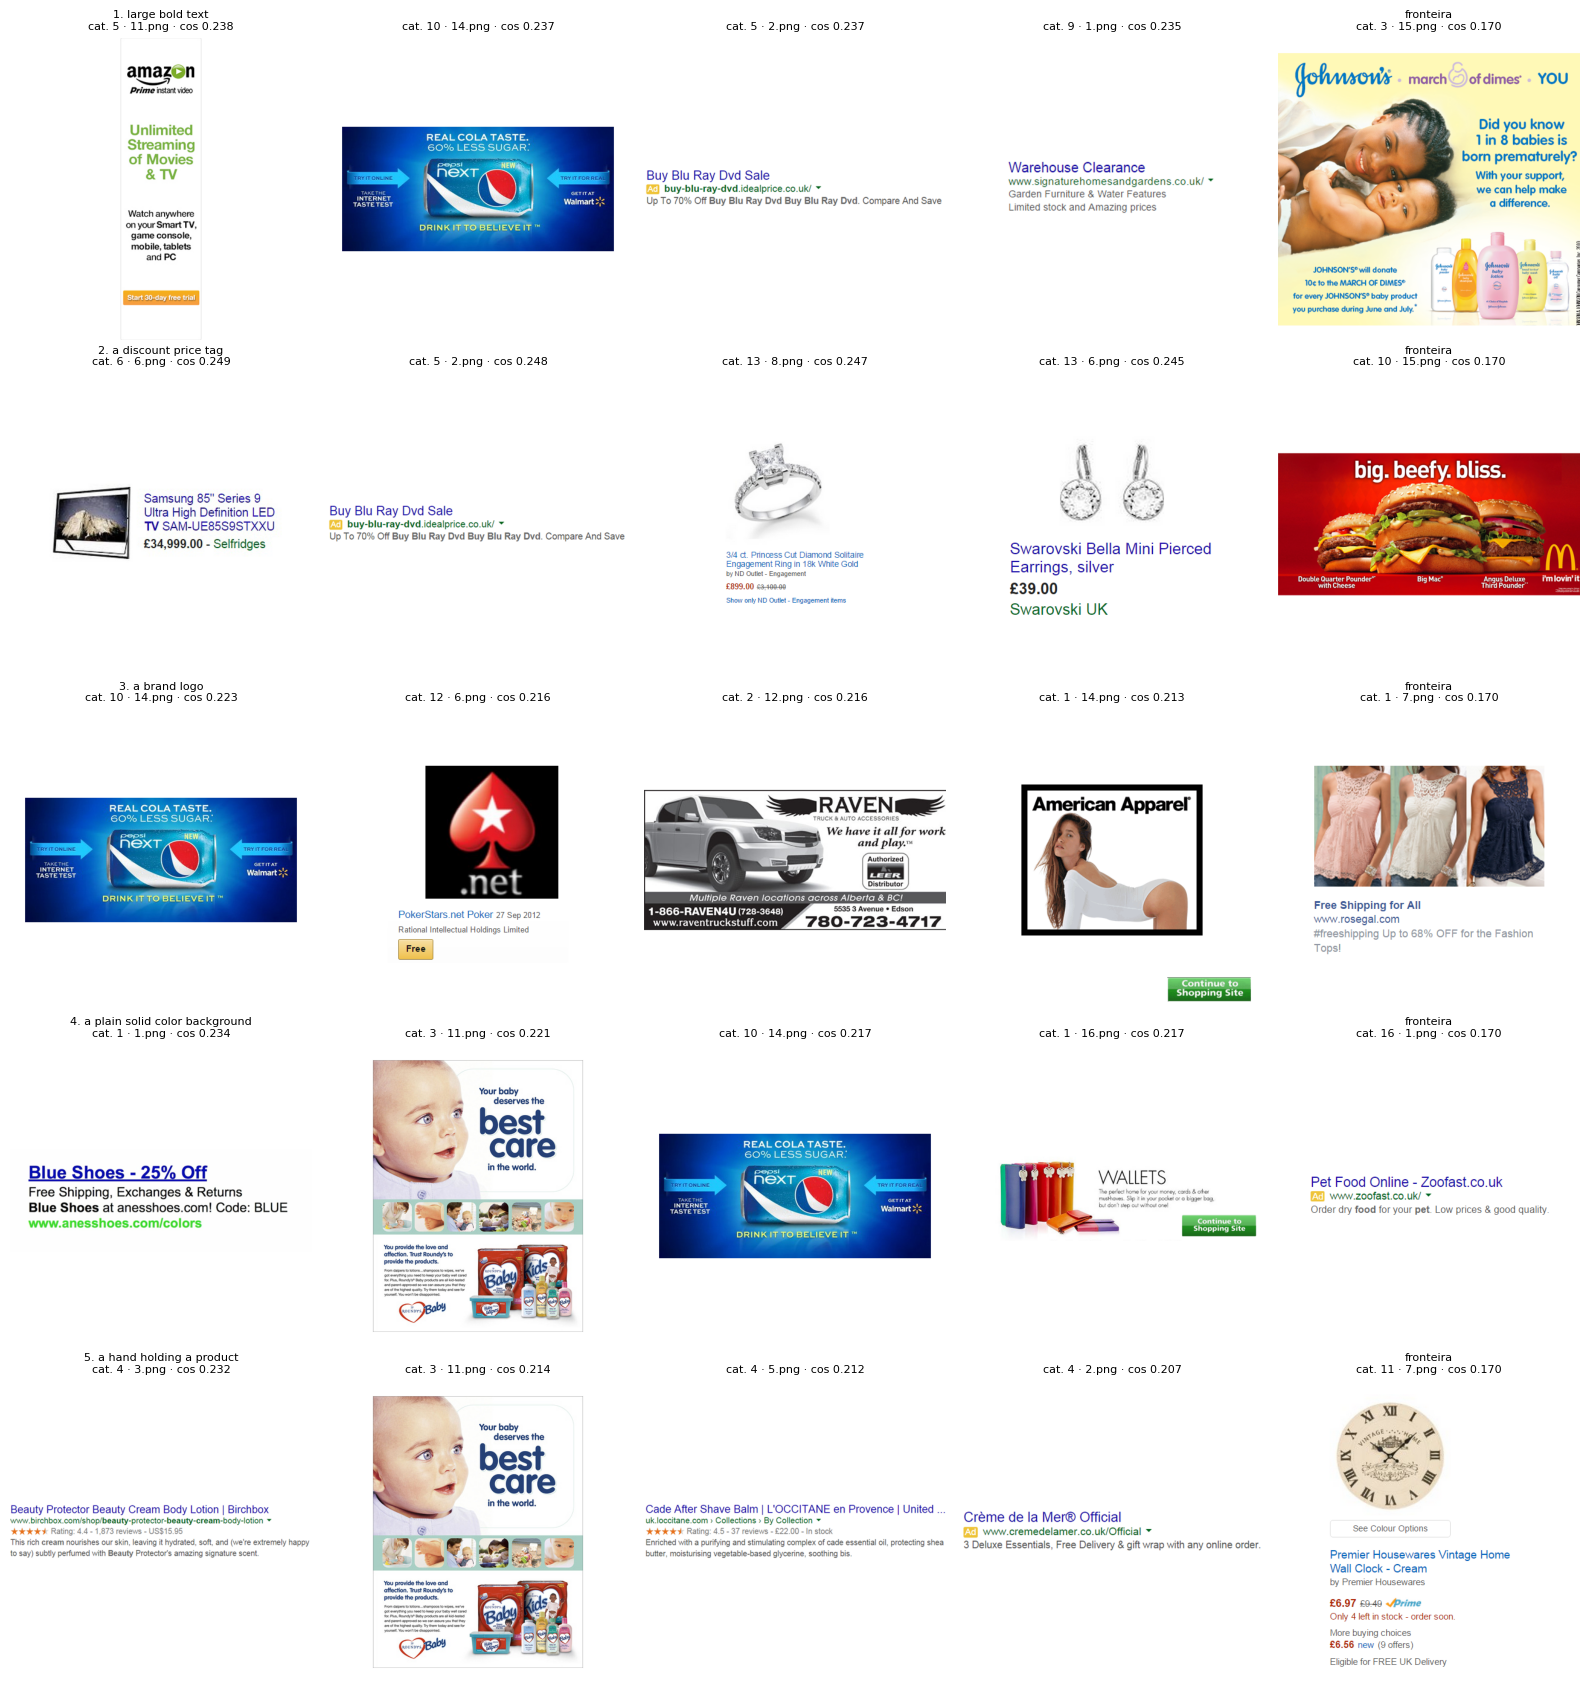

In [20]:
# Os 5 conceitos mais frequentes (R7): para cada um, os 4 anúncios de maior similaridade e 1 anúncio
# na fronteira (o de menor similaridade que ainda conta para a frequência): o caso mais fraco mostra
# melhor do que o mais forte se a frequência é confiável.
NOMES_CATEGORIAS = {}  # nº da categoria -> nome do produto (preencher a partir do artigo em Documents/)


def rotulo_categoria(categoria: int) -> str:
    return NOMES_CATEGORIAS.get(categoria, f"cat. {categoria}")


TOP5_CONCEITOS = df_ranking["conceito"].head(5).tolist()
print("Os 5 conceitos mais frequentes:", TOP5_CONCEITOS)

fig, eixos = plt.subplots(5, 5, figsize=(16, 17))
for i, conceito in enumerate(TOP5_CONCEITOS):
    s = S[:, CONCEITOS.index(conceito)]
    melhores = list(np.argsort(s)[::-1][:4])
    acima_t = np.where(s >= THRESHOLD)[0]
    # anúncio na fronteira: o de menor cosseno acima do threshold (se nenhum passa, o 5º mais similar)
    fronteira = int(acima_t[np.argmin(s[acima_t])]) if len(acima_t) else int(np.argsort(s)[::-1][4])
    for k, idx in enumerate(melhores + [fronteira]):
        r = corpus.iloc[idx]
        ax = eixos[i, k]
        ax.imshow(carregar_imagem(r["caminho"]))
        cabecalho = f"{i + 1}. {conceito}\n" if k == 0 else ("fronteira\n" if k == 4 else "\n")
        ax.set_title(f"{cabecalho}{rotulo_categoria(r['categoria'])} · {r['n']}.png · cos {s[idx]:.3f}", fontsize=8)
        ax.axis("off")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "top5_conceitos_exemplos.png", dpi=120)
plt.show()

**Interpretação do ranking.**

- **O top-5 é todo de design e marketing, nenhum objeto:** "large bold text" (255 anúncios, 85%), "a
  discount price tag" (237, 79%), "a brand logo" (136), "a plain solid color background" (97) e "a hand
  holding a product" (72). Isso reflete o corpus: boa parte dos anúncios é só texto sobre fundo branco.
- **O que se confirma nas imagens.** Os 4 melhores exemplos de "a discount price tag" mostram de fato
  **preços impressos** (TV Samsung a £34.999, anel a £899, brincos a £39). Os de "a brand logo" mostram
  logos reais (Pepsi, PokerStars, Raven, American Apparel). "a plain solid color background" é coerente
  com os anúncios de texto sobre fundo branco.
- **O que é artefato.**
  - "a discount price tag" em 79% dos anúncios não é presença literal: na fronteira entram anúncios sem
    preço (McDonald's, futebol). O CLIP associa a frase ao gênero "anúncio".
  - "a hand holding a product" (24%): os exemplos mais fortes são anúncios de texto de cosméticos e um
    anúncio de bebê, **sem nenhuma mão**.
  - "a brand logo" com 45% pode ser o erro contrário, subcontagem: quase todo anúncio tem logo, mas os
    pequenos ficam ilegíveis a 336 px.
- **Objetos concretos: raros e fortes.** "a car" e "a laptop computer" (24), "fashion clothing" (23),
  "a makeup product" e "a perfume bottle" (20) e "a wrist watch" (19) ficam perto de 15, o tamanho de
  uma categoria, e passam do corte com força (`sim_media_acima` de ~0,19). Os conceitos de layout passam
  em muitos anúncios, mas com força menor.
- **Pureza por categoria (sem rótulos, sem treino).** Os objetos concentram os positivos numa categoria:
  **14 dos 24** anúncios de "a car" estão na categoria 2, **13 dos 23** de "fashion clothing" na 1,
  **10 dos 20** de "a makeup product" na 4 e **7 dos 19** de "a wrist watch" na 13. Já os conceitos de
  layout se espalham pelas **20 categorias**: o mais comum reúne só 6% dos positivos de "large bold
  text" e 8% dos de "a brand logo". Os objetos captam produtos; os conceitos de layout captam o formato
  do anúncio, em qualquer categoria.
- **Suspeitos:** "a credit card" (51 anúncios, em 17 categorias, pureza 0,16) e "furniture" (48, em 16
  categorias, pureza 0,19) se espalham como conceitos de layout, e não como produtos: provavelmente
  respondem a formas retangulares e a banners, não ao objeto.
- **Dependência da escrita:** na sensibilidade ao template, conceitos de layout e abstratos variam mais
  ("a futuristic technology background" 0,47 de sobreposição; "a brand logo" 0,60), e pessoas e roupas
  são os mais robustos (0,87).

**Conclusão:** o ranking mede o que o CLIP associa aos anúncios deste corpus, uma mistura de conteúdo e
formato. Para objetos concretos, a frequência se aproxima de uma contagem de presença; para conceitos de
layout, ela mede afinidade com o gênero "anúncio".

## 2.2 — Busca semântica por consulta textual

### Função de busca (R8)

A consulta vira um embedding de texto normalizado; o produto interno com os embeddings das 301 imagens
(também normalizados) é o cosseno, e a função devolve os 5 maiores. A consulta entra como está, sem
templates, porque é a frase que o usuário digitaria; no ranking, o ensemble existe porque cada conceito é
uma descrição curta escrita para medir frequência.

In [21]:
def buscar_anuncios(consulta: str, top_n: int = 5):
    """Índices (no `corpus`) e cossenos das top_n imagens mais similares a uma consulta textual (R8).

    A consulta entra como está, sem templates: é a frase que o usuário digitaria. (O ranking usa
    prompt ensembling porque ali cada conceito é uma descrição curta escrita para medir frequência.)
    """
    scores = (EMB_IMAGENS @ embeddings_textos([consulta]).T).squeeze(1).numpy()  # norma 1: cosseno
    top_indices = np.argsort(scores)[::-1][:top_n]
    return top_indices, scores[top_indices]

### Consultas (R9)

13 consultas, variando em **especificidade** (genérica → específica) e **abstração** (concreta →
abstrata). As duas últimas testam se o CLIP lê o texto impresso no anúncio: a 13ª é um controle, a mesma
frase com uma palavra que não deve aparecer nos anúncios.

| # | Consulta | Especificidade | Abstração | O que se esperava recuperar |
|---|---|---|---|---|
| 1 | a car | genérica | concreta | anúncios com foto de carro |
| 2 | a luxury red sports car driving fast | específica | concreta | carro esportivo vermelho, em movimento |
| 3 | a wrist watch | genérica | concreta | relógios de pulso |
| 4 | a minimalist luxury wrist watch close-up | específica | concreta | relógio de pulso em close, fundo limpo |
| 5 | a happy smiling woman | genérica | concreta | mulheres sorrindo |
| 6 | a professional businesswoman working on a computer | específica | concreta | mulher em escritório, com computador |
| 7 | a discount promotion | genérica | intermediária | anúncios de promoção |
| 8 | special offer with a high percentage discount | específica | intermediária | anúncios com "%" em destaque |
| 9 | luxury | genérica | abstrata | produtos de alto padrão (joias, relógios) |
| 10 | freedom and adventure | genérica | abstrata | viagem, natureza, esportes ao ar livre |
| 11 | a healthy lifestyle | intermediária | abstrata | comida saudável, esporte |
| 12 | the word "SALE" written in large letters | específica | texto impresso | anúncios com "SALE" escrito |
| 13 | the word "THURSDAY" written in large letters | específica | texto impresso (controle) | nada específico: se vier o mesmo que a 12, o modelo responde a "letras grandes", não à palavra |

,consulta,especificidade,abstração
1,a car,genérica,concreta
2,a luxury red sports car driving fast,específica,concreta
3,a wrist watch,genérica,concreta
4,a minimalist luxury wrist watch close-up,específica,concreta
5,a happy smiling woman,genérica,concreta
6,a professional businesswoman working on a comp...,específica,concreta
7,a discount promotion,genérica,intermediária
8,special offer with a high percentage discount,específica,intermediária
9,luxury,genérica,abstrata
10,freedom and adventure,genérica,abstrata


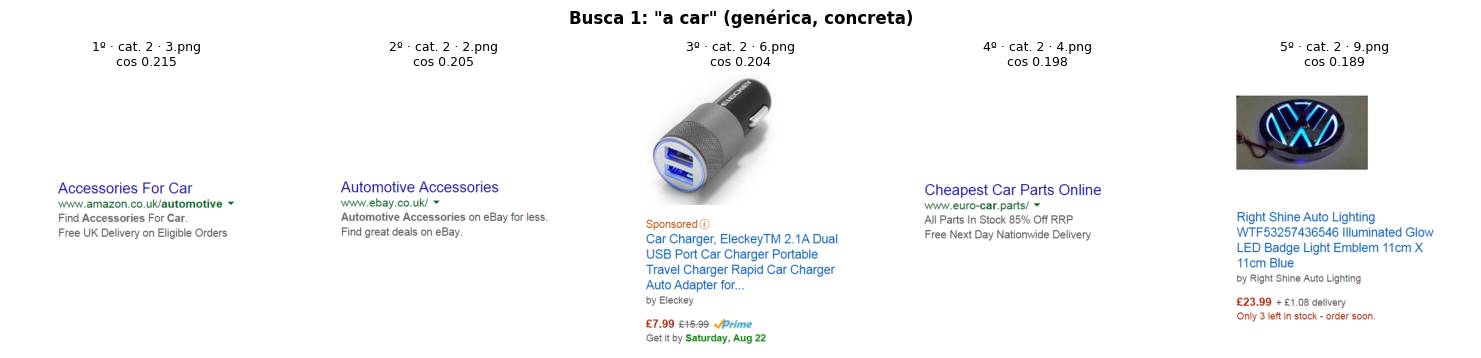

  Atenção: quase-duplicatas no top-5: 2/2.png × 2/3.png


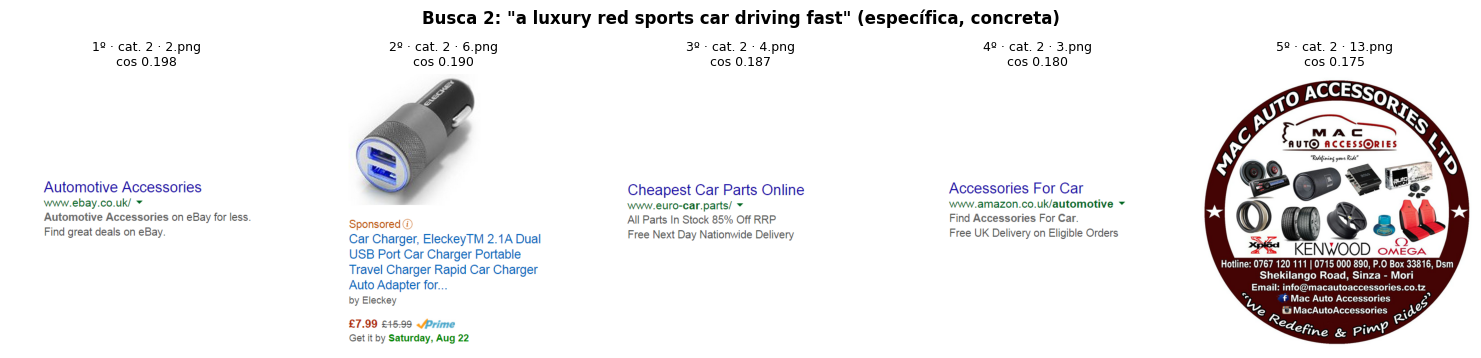

  Atenção: quase-duplicatas no top-5: 2/2.png × 2/3.png


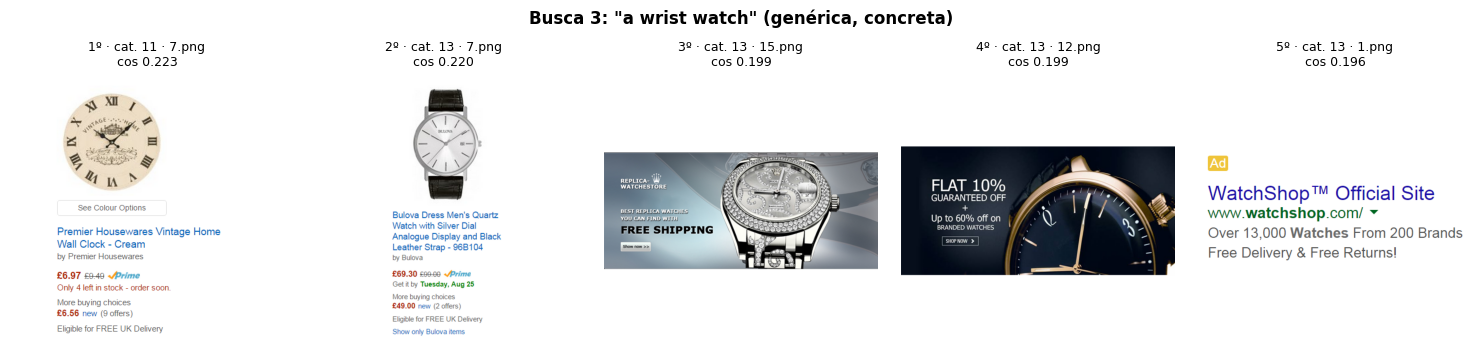

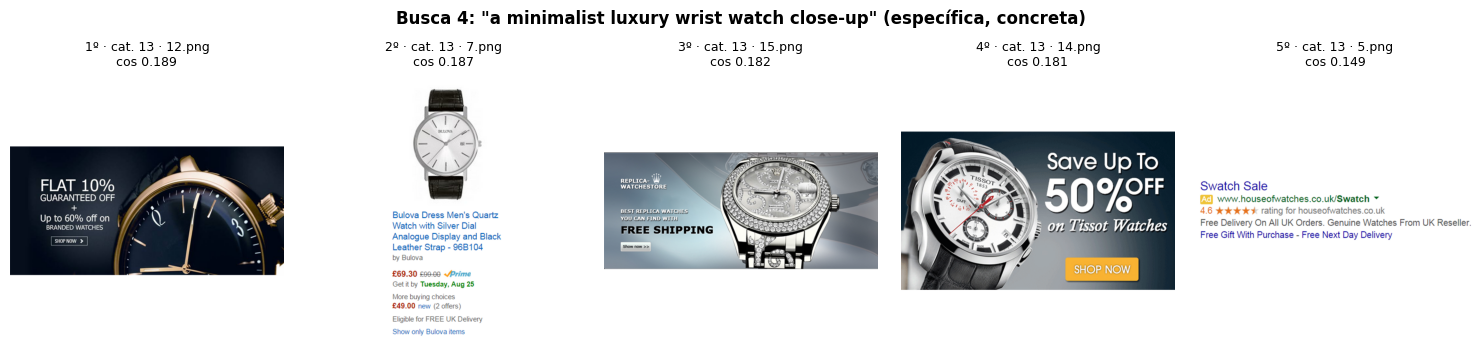

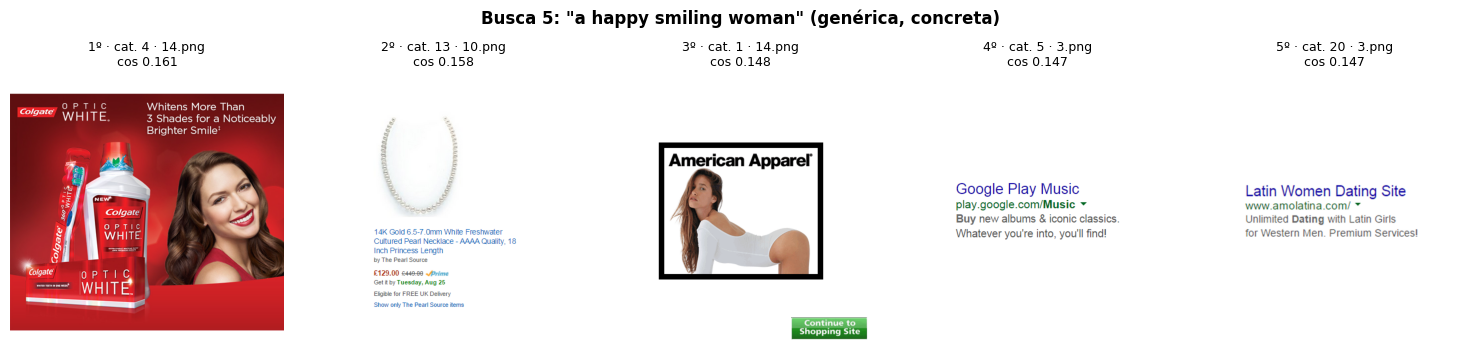

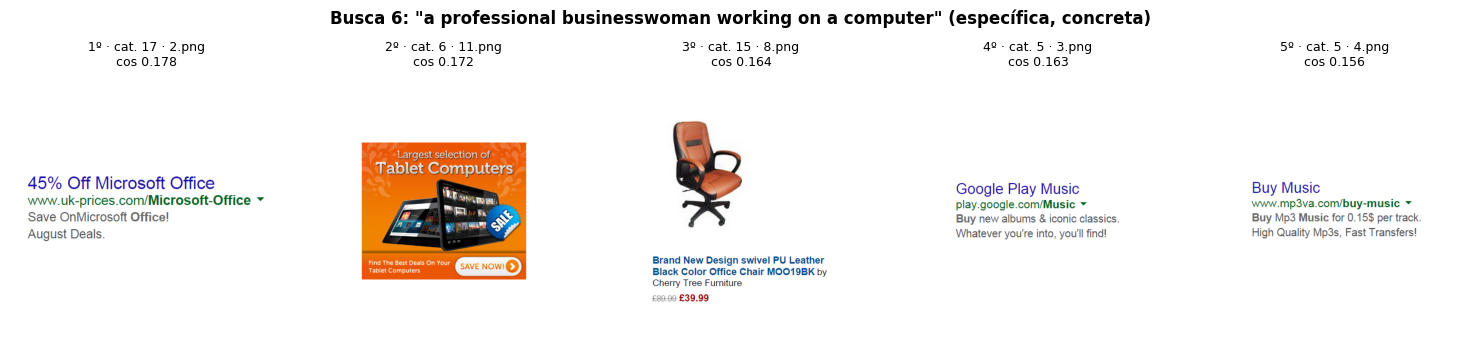

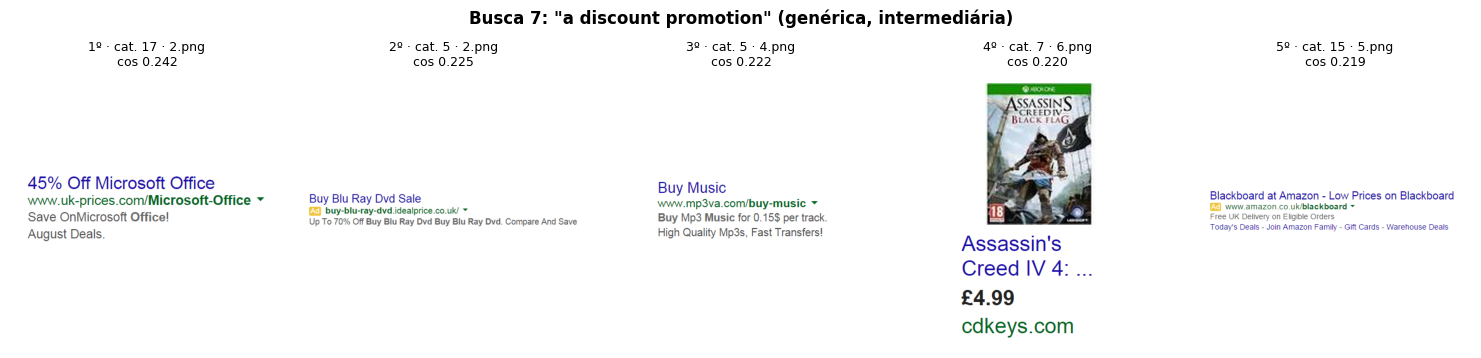

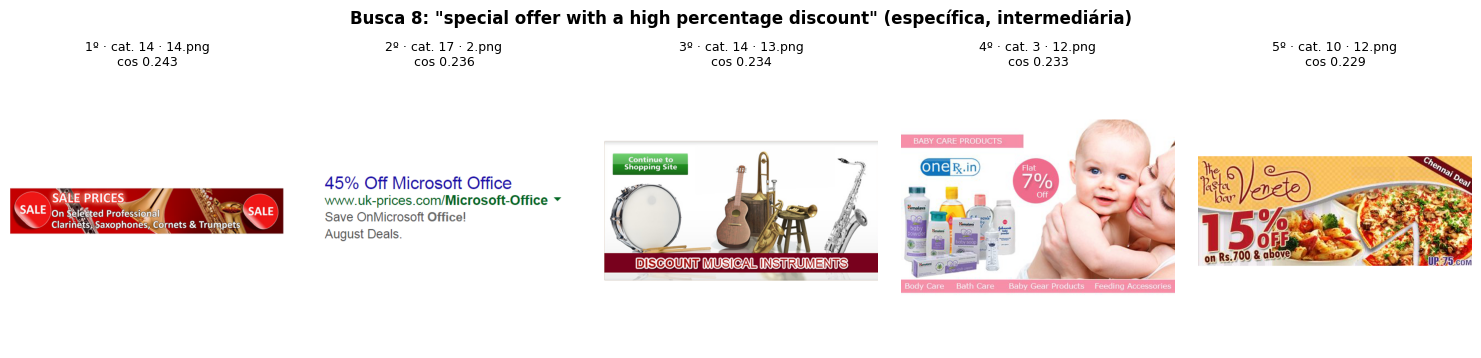

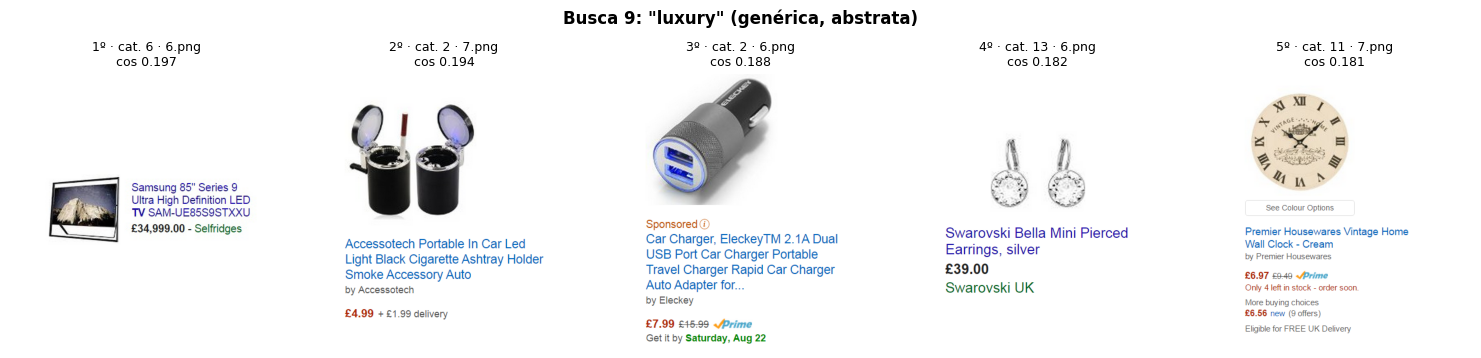

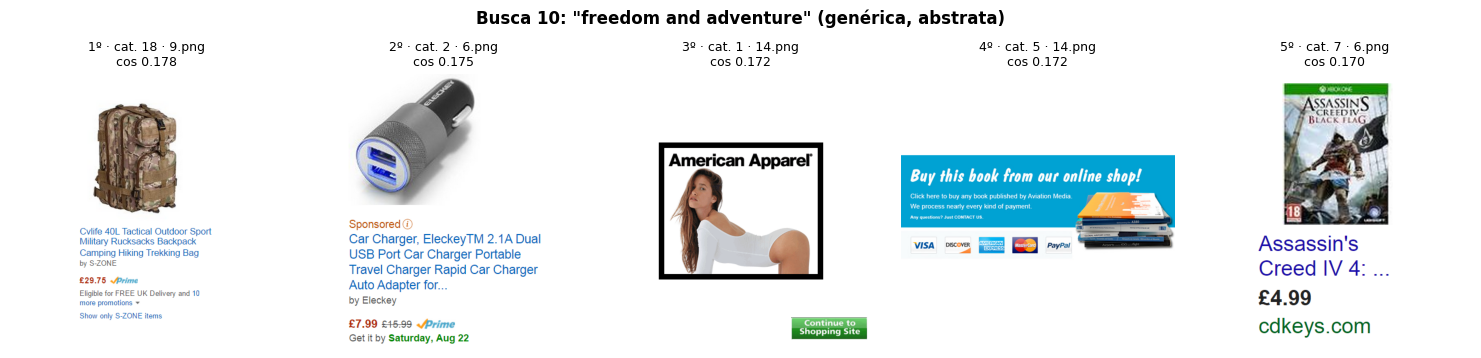

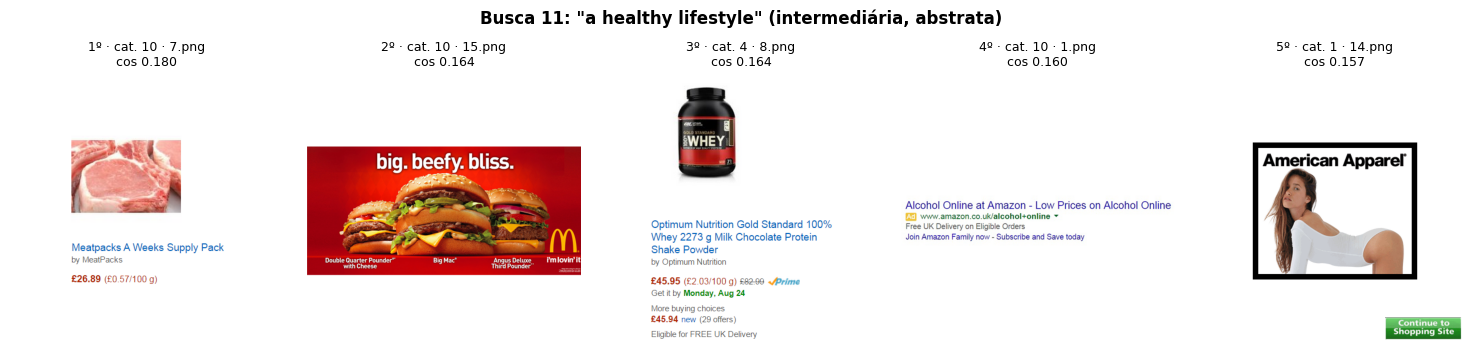

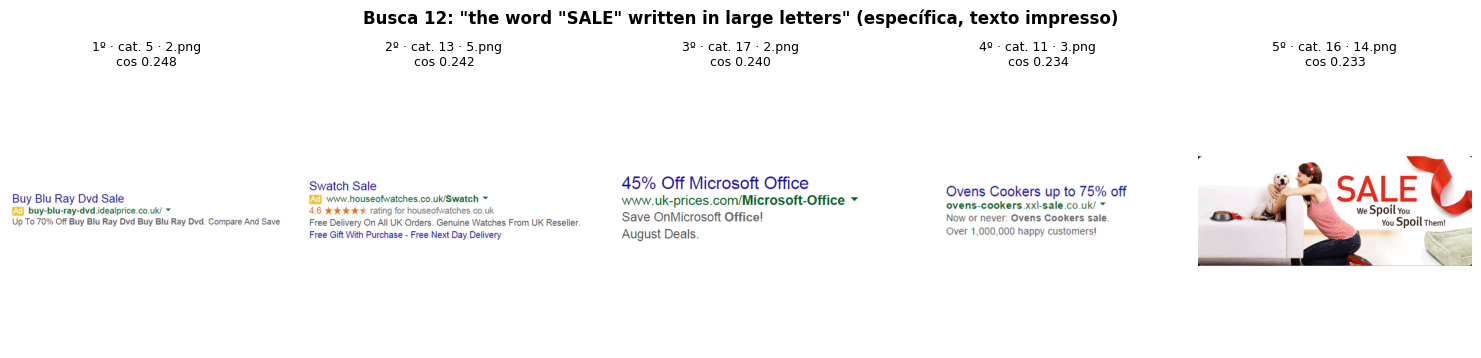

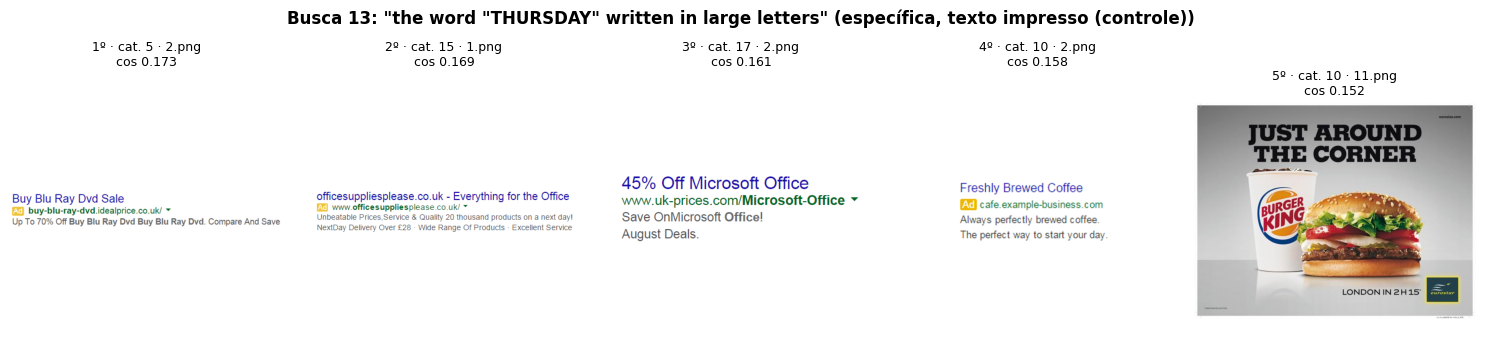

posicao,1,2,3,4,5
consulta,,,,,
1,0.2151,0.2048,0.2040,0.1984,0.1888
2,0.1977,0.1900,0.1870,0.1800,0.1751
3,0.2227,0.2203,0.1993,0.1988,0.1957
4,0.1889,0.1869,0.1823,0.1814,0.1493
5,0.1610,0.1581,0.1481,0.1475,0.1473
6,0.1776,0.1723,0.1636,0.1635,0.1561
7,0.2422,0.2245,0.2221,0.2196,0.2192
8,0.2431,0.2357,0.2345,0.2326,0.2294
9,0.1968,0.1936,0.1877,0.1818,0.1812


Top-5 em comum entre SALE e o controle: 2 de 5; cosseno médio 0.239 × 0.163


In [22]:
# Consultas (R9): variam em especificidade (genérica -> específica) e abstração (concreta -> abstrata).
# As duas últimas testam se o CLIP lê o texto impresso ou só reconhece o layout: a 13ª é um controle,
# a mesma frase com uma palavra que não deve aparecer nos anúncios. Se o top-5 e os cossenos quase não
# mudam, o modelo responde a "letras grandes", não ao conteúdo do texto.
CONSULTAS = pd.DataFrame([
    ("a car", "genérica", "concreta"),
    ("a luxury red sports car driving fast", "específica", "concreta"),
    ("a wrist watch", "genérica", "concreta"),
    ("a minimalist luxury wrist watch close-up", "específica", "concreta"),
    ("a happy smiling woman", "genérica", "concreta"),
    ("a professional businesswoman working on a computer", "específica", "concreta"),
    ("a discount promotion", "genérica", "intermediária"),
    ("special offer with a high percentage discount", "específica", "intermediária"),
    ("luxury", "genérica", "abstrata"),
    ("freedom and adventure", "genérica", "abstrata"),
    ("a healthy lifestyle", "intermediária", "abstrata"),
    ('the word "SALE" written in large letters', "específica", "texto impresso"),
    ('the word "THURSDAY" written in large letters', "específica", "texto impresso (controle)"),
], columns=["consulta", "especificidade", "abstração"])
CONSULTAS.index += 1
display(CONSULTAS)

resultados = []
for q, linha in CONSULTAS.iterrows():
    indices, scores = buscar_anuncios(linha["consulta"], top_n=5)
    duplicatas_no_top5 = [par for par in PARES_QUASE_DUPLICATAS if set(par) <= set(indices.tolist())]

    fig, eixos = plt.subplots(1, 5, figsize=(15, 3.4))
    fig.suptitle(f'Busca {q}: "{linha["consulta"]}" ({linha["especificidade"]}, {linha["abstração"]})',
                 fontsize=12, fontweight="bold", y=1.04)
    for pos_top, (idx, score) in enumerate(zip(indices, scores), start=1):
        r = corpus.iloc[idx]
        eixos[pos_top - 1].imshow(carregar_imagem(r["caminho"]))
        eixos[pos_top - 1].set_title(f"{pos_top}º · {rotulo_categoria(r['categoria'])} · {r['n']}.png\ncos {score:.3f}",
                                     fontsize=9)
        eixos[pos_top - 1].axis("off")
        resultados.append({"consulta": q, "texto": linha["consulta"], "posicao": pos_top,
                           "categoria": r["categoria"], "n": r["n"], "cosseno": round(float(score), 4)})
    plt.tight_layout()
    fig.savefig(DIR_REPORT_ASSETS / f"busca_q{q}.png", dpi=120, bbox_inches="tight")
    plt.show()
    if duplicatas_no_top5:
        print("  Atenção: quase-duplicatas no top-5: "
              + ", ".join(f"{nome_anuncio(a)} × {nome_anuncio(b)}" for a, b in duplicatas_no_top5))

# Registro dos resultados (R10): uma linha por consulta × posição
df_busca = pd.DataFrame(resultados)
df_busca.to_csv(DIR_REPORT_ASSETS / "busca_resultados.csv", index=False)
display(df_busca.pivot(index="consulta", columns="posicao", values="cosseno"))

# Teste de leitura: quantos anúncios do top-5 de "SALE" se repetem no controle, e a diferença de cosseno
top5 = {q: set(zip(g["categoria"], g["n"])) for q, g in df_busca.groupby("consulta")}
q_sale, q_controle = CONSULTAS.index[-2], CONSULTAS.index[-1]
media = df_busca.groupby("consulta")["cosseno"].mean()
print(f"Top-5 em comum entre SALE e o controle: {len(top5[q_sale] & top5[q_controle])} de 5; "
      f"cosseno médio {media[q_sale]:.3f} × {media[q_controle]:.3f}")

### Análise das consultas (R11)

Os cossenos de consultas diferentes não são comparáveis diretamente (cada frase tem a sua própria base);
o que se compara é o formato da curva dentro de cada consulta: uma queda indica que poucos anúncios
correspondem, e uma curva plana, que nenhum se destaca.

**Busca 1, "a car".** As 5 são da categoria 2 (peças e acessórios de carro, pelo que mostram as
imagens), mas **nenhuma é foto de carro**: 3 são anúncios só de texto com "Car" ou "Automotive" no título
(`2/3`, `2/2`, `2/4`), 1 é um carregador veicular e 1 um emblema de carro. O corpus não tem fotos de
carros inteiros: o CLIP chegou à categoria certa **lendo a palavra "car"**. O par quase duplicado `2/2` ×
`2/3` ocupou duas vagas.

**Busca 2, "a luxury red sports car driving fast".** Quase as mesmas imagens da busca 1, reordenadas,
mais o logo circular de uma loja de acessórios automotivos. Não existe carro esportivo vermelho no corpus,
então a consulta específica não tem para onde ir e cai no "car". Os cossenos ficam menores (0,198 →
0,175): os detalhes ausentes da imagem reduzem a similaridade sem mudar o que é recuperado. O par
quase duplicado volta a ocupar duas vagas.

**Busca 3, "a wrist watch".** O 1º é um **relógio de parede** (`11/7`): mostrador redondo com algarismos
confunde "clock" e "watch". Do 2º ao 5º, só categoria 13 (relógios e joias, pelo que mostram as imagens): 3 fotos de relógio de pulso
e 1 anúncio de texto da WatchShop. Bom resultado, com um erro visual compreensível.

**Busca 4, "a minimalist luxury wrist watch close-up".** As 5 são da categoria 13. As 4 primeiras são
fotos de relógio de pulso (0,189 → 0,181), e há uma **queda nítida no 5º** (0,149), um anúncio só de texto
("Swatch Sale"): só existem 4 imagens que correspondem à consulta. "Minimalist" quase não pesou: um
relógio cravejado de diamantes aparece em 3º.

**Busca 5, "a happy smiling woman".** Só o 1º atende (anúncio da Colgate com uma mulher sorrindo). Vêm
depois um colar de pérolas sem pessoa, a mulher do anúncio da American Apparel (sem sorriso), um anúncio
de texto do Google Play Music e um anúncio de texto de site de namoro com "**Women**" no título. É a busca
com os **cossenos mais baixos** (0,161 → 0,147): há pouquíssimas fotos de pessoas no corpus e, sem a
imagem, o CLIP cai na palavra.

**Busca 6, "a professional businesswoman working on a computer".** **Nenhuma mulher.** Vêm o anúncio de
texto "45% Off Microsoft **Office**", um banner de "Tablet **Computers**", uma cadeira de escritório e dois
anúncios de texto de música. A recuperação foi por palavras ("office", "computer") e por objetos de
escritório, não pela pessoa descrita.

**Busca 7, "a discount promotion".** 4 dos 5 são anúncios só de texto com termos de oferta ("45% Off",
"Sale", "Up To 70% Off", "Low Prices") e o 5º é um jogo a £4,99. Semanticamente correto, mas pelo
**texto**, não por elementos visuais de promoção.

**Busca 8, "special offer with a high percentage discount".** Aqui a resposta muda de tipo: 4 dos 5 são
**banners visuais com "SALE" ou "%" em destaque** (instrumentos musicais, produtos de bebê com "7% off",
pizzaria com "15% OFF"), mais o anúncio "45% Off Microsoft Office". A palavra "percentage" puxou o
símbolo "%" grande.

**Busca 9, "luxury".** Uma TV Samsung de £34.999 e brincos Swarovski se ligam a luxo; um cinzeiro LED de
carro, um carregador de carro e um relógio de parede, não. A curva é quase plana (0,197 → 0,181): nenhuma
imagem se destaca, e o CLIP parece responder a pistas visuais genéricas (metal, brilho, luz azul) mais
do que ao conceito.

**Busca 10, "freedom and adventure".** Curva quase plana (0,178 → 0,170). Uma mochila de trekking e o
jogo Assassin's Creed (aventura de piratas) fazem sentido; o carregador de carro, a American Apparel e
uma loja de livros, não. Sem correlato visual direto no corpus, o modelo recorre a associações fracas.

**Busca 11, "a healthy lifestyle".** O resultado é quase o **oposto** do esperado: carne, hambúrgueres do
McDonald's, whey protein, um anúncio de **álcool** e a American Apparel. O CLIP captou o **tema** (comida,
nutrição, corpo), mas não a **polaridade** ("saudável"). Ele é bom em tópico e fraco em julgamento de
valor.

**Busca 12, the word "SALE" written in large letters.** Os 5 têm "Sale" ou "off" escrito: 4 são
anúncios só de texto, com a palavra em **fonte pequena** ("Dvd Sale", "Swatch Sale", "45% Off",
"up to 75% off… sale"), e 1 é um banner com "SALE" grande. São os maiores cossenos de todas as buscas
(0,248 → 0,233). É uma evidência forte de que o CLIP **lê o texto da imagem**, mesmo pequeno.

**Busca 13, controle com "THURSDAY".** Só **2 dos 5** anúncios se repetem em relação à busca 12
(`5/2` "Dvd Sale" e `17/2` "45% Off Microsoft Office", dois anúncios de texto genéricos), e **nenhum** dos
5 tem a palavra "Thursday": vêm anúncios de texto de material de escritório e de café, e um banner do
Burger King com letras grandes. O cosseno médio cai de **0,239 para 0,163**. Conclusão: o formato
"anúncio de texto" explica uma parte da semelhança (os 2 em comum), mas é a **palavra** que leva os
anúncios com "Sale" ao topo. O CLIP lê o texto, e não só reconhece o layout.

**Padrões.**
1. **O CLIP lê texto.** Como boa parte do corpus é anúncio de texto, muitas consultas concretas foram
   respondidas pela **palavra** (car, office, women, sale), e não pelo objeto (buscas 1, 5, 6, 7 e 12);
   o controle da busca 13 confirma que é a palavra, e não só o formato.
2. **Especificidade sem correspondência no corpus** reduz o cosseno sem trazer imagens novas
   (buscas 2 e 4).
3. **Consultas abstratas** dão curvas planas e associações por estereótipo (9 e 10), ou acertam o tema
   e erram a polaridade (11).
4. **Quase-duplicatas** ocuparam 2 das 5 vagas nas buscas 1 e 2.

In [23]:
# Evidência para o R14: tokenização da consulta no CLIP, padding e attention mask.
tok = processor.tokenizer
print(f"Tokenizador: {type(tok).__name__}; vocabulário {tok.vocab_size}; contexto máximo {tok.model_max_length}")
print(f"Tokens especiais: início {tok.bos_token!r}, fim {tok.eos_token!r}, padding {tok.pad_token!r}")

frases = ["a car", 'the word "SALE" written in large letters']
lote = tok(frases, padding=True, return_tensors="pt")
for frase, ids, mascara in zip(frases, lote["input_ids"], lote["attention_mask"]):
    print(f"\n{frase!r}\n  tokens: {tok.convert_ids_to_tokens(ids.tolist())}\n  attention_mask: {mascara.tolist()}")

# O padding não muda o embedding (a máscara faz o modelo ignorar os tokens de padding):
sozinha = embeddings_textos(["a car"])
no_lote = embeddings_textos(frases)[:1]
print(f"\nCosseno entre 'a car' sozinha e dentro do lote com padding: {float(sozinha @ no_lote.T):.6f}")

Tokenizador: CLIPTokenizer; vocabulário 49408; contexto máximo 77
Tokens especiais: início '<|startoftext|>', fim '<|endoftext|>', padding '<|endoftext|>'

'a car'
  tokens: ['<|startoftext|>', 'a</w>', 'car</w>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>', '<|endoftext|>']
  attention_mask: [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]

'the word "SALE" written in large letters'
  tokens: ['<|startoftext|>', 'the</w>', 'word</w>', '"</w>', 'sale</w>', '"</w>', 'written</w>', 'in</w>', 'large</w>', 'letters</w>', '<|endoftext|>']
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Cosseno entre 'a car' sozinha e dentro do lote com padding: 1.000000


## Discussão (R12, R13, R14)

### Alinhamento das representações visuais e textuais (R12)

O CLIP tem dois codificadores independentes, um ViT para a imagem e um Transformer para o texto, e cada
um termina numa projeção linear para o **mesmo espaço de 768 dimensões**. Com os vetores normalizados, a
similaridade é o cosseno, e "alinhado" quer dizer que a imagem e a frase que a descreve ficam próximas
nesse espaço.

**O que os números mostram.**
- **Imagem × texto:** de 0,034 a 0,249, mediana 0,137, P95 0,199. Mesmo as consultas mais bem
  respondidas não passam de ~0,25.
- **Imagem × imagem:** mediana **0,488**, P95 0,717, máximo 0,941. Até o vizinho de um anúncio
  "diferente" (`1/16.png` × `6/11.png`, 0,758) fica muito acima de qualquer par imagem × texto.

Comparando típico com típico: a mediana imagem × imagem (0,488) é **3,6 vezes** a mediana imagem × texto
(0,137), e mesmo dois anúncios sem relação entre si costumam ser mais parecidos do que um anúncio e a
frase que o descreve.

Isso é o **modality gap** (Liang et al., 2022): os embeddings de cada modalidade ocupam regiões
distintas e estreitas do espaço, e há um deslocamento entre os centros das duas. Um par imagem-texto
correto nunca chega perto de 1; o que carrega a informação é a **ordem relativa**, e não o valor
absoluto. Consequência prática: o threshold do ranking precisa vir da distribuição observada.

O alinhamento também inclui **texto renderizado**: a palavra escrita no anúncio fica perto da mesma
palavra na consulta (buscas 1, 5, 6 e 12). É o fenômeno conhecido como "ataque tipográfico": no artigo e
no blog da OpenAI, um papel escrito "iPod" colado numa maçã faz o CLIP ver um iPod. Neste corpus, cheio
de anúncios de texto, esse efeito domina boa parte das buscas.

### Por que o pré-treino contrastivo permite recuperação sem treino supervisionado (R13)

O CLIP foi treinado com **400 milhões de pares imagem-texto** da web. Em cada lote (32.768 pares no
artigo), o objetivo contrastivo **aproxima os N pares corretos e afasta os N² − N incorretos**, nas duas
direções (imagem → texto e texto → imagem), com uma temperatura aprendida que controla o quão "afiada" é
a distribuição de similaridades.

O texto livre funciona como um **rótulo aberto**: em vez de um conjunto fixo de classes, o modelo aprende
qualquer conceito que apareça em legendas. Depois do pré-treino, qualquer frase nova vira um ponto no
mesmo espaço, e classificar ou buscar passa a ser medir proximidade, sem treinar nada. Foi o que
permitiu, neste notebook, ranquear 25 conceitos e responder 13 consultas sem nenhum rótulo do ADS-16.

**Contraste com a A1:** o ViT pré-treinado no ImageNet tinha um head de 1.000 classes fixas; para as 7
classes de lesões, foi preciso trocar o head e fazer fine-tuning com dados rotulados. O CLIP dispensa
isso porque o "head" é o próprio codificador de texto.

**Limites vistos aqui:** o modelo lê o texto da imagem e se deixa guiar por ele; acerta o tema e erra a
polaridade ("a healthy lifestyle"); e conceitos abstratos geram associações fracas. Ele só sabe o que
estava, com frequência, nos dados da web.

### Consulta textual do CLIP × tokenização no BERT: padding e attention mask (R14)

**Em comum:** os dois tokenizam em subpalavras e, num lote, completam as frases curtas com **padding**
até a mais longa. A **attention mask** (1 = token real, 0 = padding) impede que os tokens de padding
entrem no cálculo da atenção.

**Diferenças** (a célula acima mostra os tokens e a máscara de duas consultas; no CLIP, os tokens
especiais são `<|startoftext|>` e `<|endoftext|>`, o vocabulário tem 49.408 tokens e o tokenizador
converte tudo para minúsculas: "SALE" vira `sale`):

| | CLIP (texto) | BERT |
|---|---|---|
| Tokenizador | BPE em bytes, ~49 mil tokens | WordPiece, ~30 mil tokens |
| Contexto máximo | **77 tokens** | 512 tokens |
| Tokens especiais | início e fim de texto | `[CLS]`, `[SEP]`, `[PAD]` |
| Token de padding | **o próprio token de fim de texto** | `[PAD]`, um token próprio |
| Atenção | **causal** (cada token só vê os anteriores) | bidirecional |
| Vetor da frase | estado do **primeiro** token de fim de texto, projetado para 768 | estado do `[CLS]` (ou média dos tokens) |

**O papel do padding e da máscara em cada um.**
- **No BERT**, a atenção é bidirecional: sem a máscara, o `[CLS]` atenderia aos `[PAD]`, e o vetor da
  frase mudaria conforme o tamanho das outras frases do lote. A máscara é essencial.
- **No CLIP**, o padding usa o mesmo token de fim de texto. Por isso o modelo pega a **primeira**
  ocorrência dele (no código do transformers, a posição do primeiro `eos_token_id`). Como a atenção é
  causal, esse token só vê os tokens anteriores a ele, ou seja, a frase. O padding vem depois e não chega
  ao vetor da frase. A máscara continua sendo aplicada, junto com a máscara causal.
- **Evidência:** na célula acima, "a car" ocupa 4 tokens e recebe 7 de padding (máscara
  `[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]`) para igualar a outra frase do lote. O embedding de "a car"
  calculado sozinho e dentro desse lote tem **cosseno 1,000000**: o padding não muda a consulta.

## Apêndice: versões e tempo/memória (R15)

In [24]:
import platform
import resource
from importlib.metadata import version

import huggingface_hub
import matplotlib
import PIL
import transformers

# Versões (para o requirements.txt e a reprodutibilidade)
print(f"Python {platform.python_version()} · torch {torch.__version__} · transformers {transformers.__version__} · "
      f"huggingface_hub {huggingface_hub.__version__} · kagglehub {version('kagglehub')}")
print(f"numpy {np.__version__} · pandas {pd.__version__} · Pillow {PIL.__version__} · matplotlib {matplotlib.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'nenhuma (CPU)'} · "
      f"SO {platform.system()} {platform.release()}")

# Tempo e memória por etapa (os picos de VRAM são por etapa: o contador é zerado no início de cada uma)
df_tempos = pd.DataFrame(TEMPOS)
df_tempos.to_csv(DIR_REPORT_ASSETS / "tempos_execucao.csv", index=False)
display(df_tempos)

tempo_total = time.perf_counter() - _T_INICIO_NOTEBOOK
# ru_maxrss: pico de memória residente do processo desde o início (em KB no Linux)
pico_ram_gb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6
pico_alocada = df_tempos["pico_vram_gb"].max() if "pico_vram_gb" in df_tempos else float("nan")
pico_reservada = df_tempos["pico_vram_reservada_gb"].max() if "pico_vram_reservada_gb" in df_tempos else float("nan")
print(f"Tempo total do notebook: {tempo_total:.0f} s ({tempo_total / 60:.1f} min), "
      f"dos quais {df_tempos['segundos'].sum():.0f} s nas etapas cronometradas")
print(f"Pico de VRAM: alocada {pico_alocada} GB, reservada {pico_reservada} GB")
print(f"Pico de RAM do processo: {pico_ram_gb:.1f} GB")
print("Download do ADS-16: veio do cache do Colab?" , "sim" if str(DIR_ADS16).startswith("/kaggle/input") else "não")

Python 3.13.15 · torch 2.11.0+cu130 · transformers 5.17.0 · huggingface_hub 1.31.0 · kagglehub 1.0.2
numpy 2.1.3 · pandas 2.2.3 · Pillow 11.3.0 · matplotlib 3.10.0
GPU: Tesla T4 · SO Linux 6.6.122+


,etapa,segundos,pico_vram_gb,pico_vram_reservada_gb
0,clone/pull do repositório,1.6,NaN,NaN
1,download do ADS-16,25.6,NaN,NaN
2,carregamento do CLIP,14.3,1.71,1.76
3,embeddings das imagens,33.9,2.98,3.38
4,embeddings dos conceitos,1.4,NaN,NaN


Tempo total do notebook: 134 s (2.2 min), dos quais 77 s nas etapas cronometradas
Pico de VRAM: alocada 2.98 GB, reservada 3.38 GB
Pico de RAM do processo: 3.2 GB
Download do ADS-16: veio do cache do Colab? não
